<a href="https://colab.research.google.com/github/absr2309/WBP3/blob/main/WBP3_Scottish_Crime_Data_Analysis_Clustering_and_Future_Rate_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Scottish Crime Data Analysis: Clustering and Future Rate Prediction**

## **1.0 Foreword**
All crime values are taken from Table 4 of the Scottish Government Recorded Crime in Scotland Statistics 2024-25, which reports crime rates per 10,000 population. Therefore, all analyses, visualisations and clustering are based on population-standardised rates rather than raw counts.

### **2.0 Introduction**
This notebook analyses adjusted crime rate data from the Scottish Government Recorded Crime in Scotland Statistics 2024-25. The project has a full data science workflow from data preparation, exploratory analysis, feature engineering, machine learning and predictive modelling for the three identified Police Scotland priority crime types of fraud, shoplifting and domestic abuse:

* Data Cleansing and Preparation: Load the dataset, perform extensive cleaning such as removing whitespace and changing n/r to 0, filter the data for specific years (last three), remove the national Scotland aggregate and any rows that are just totals, clean down labels removing instances that include [note x] and renaming Domestic Abuse Scotland (2018) label to Domestic Abuse, and reshape/melt the data from a 'wide' format into a 'long' format.

* Exploratory Data Analysis (EDA): Generate descriptive statistics for the three crime types, total crime rates for the three crime types per Local Authority for the clustering, produce a grouped bar chart for the crime types across all local authorities, visualise a heatmap of crime rates by local authority and crime type, view the top ten local authorities for these specific crime types, see the distribution of crime types on boxplots, and calculate the correlation matrix for crime features.

 * Feature Engineering and Unsupervised Learning (K-Means Clustering): Clustering will be first applied to the absolute crime rate features to group local authorities with similar crime profiles. Year-on-Year (YoY) change metrics will be created to capture directional trends, followed by clustering on these change-based features. Both clustering stages will include optimal k selection using the Elbow Method, feature scaling, in-depth cluster interpretation, and visualisation of the resulting cluster patterns.
  
 * Supervised Learning (Linear Regression): Train the model and evaluate the regression using appropriate metrics (R-squared, MAE, RMSE) to forecast crime rates for the next three years for each crime type.

 * Overall Visualisations: Effective use of multiple plot types (bar charts, heatmaps, box plots, line charts) to convey insights, with attention to readability and colour blind accessibility.



#### **2.1 Data Cleansing and Preparation**
Data is loaded and cleased, whitespace removed and n/r changed to 0, data is filtered for the last three years, the national Scotland aggregate and any rows that are just totals are removed, labels are cleaned down to remove instances that include [note x] and Domestic Abuse Scotland (2018) label is renamed to Domestic Abuse, data is reshaped/melted from a 'wide' format into a 'long' format. Resulting dataset is saved as 'cleaned_crime_data.csv'.

In [3]:
import pandas as pd # Import the pandas library for data manipulation and analysis
import re # Import the regular expression module for pattern matching and string cleaning

# 1. Load the dataset
df = pd.read_csv('Recorded_Crime.csv', skiprows=2, header=0)

# 2. Global Clean: Remove whitespace and change 'n/r' to 0
df = df.map(lambda x: x.strip() if isinstance(x, str) else x) # Changed applymap to map
df.replace(['n/r', '-', '..'], 0, inplace=True)

# 3. Targeted Row Filtering
# Remove the national 'Scotland' aggregate and any rows that are just totals
# This prevents double-counting in visuals
df_filtered = df[
    (df['Local Authority'] != 'Scotland') &
    (~df['Crime group'].str.contains('Total', case=False, na=False)) &
    (~df['Crime type'].str.contains('Total', case=False, na=False)) & # Re-added this filter for 'Crime type'
    (~df['Local Authority'].isin(['Go to Notes', 'Return to index']))
].copy()

# 4. Clean Labels: Remove [note 1], [note 2], etc.
# This regex targets the brackets, the word 'note', and any digit (1-4+). Made more general to catch variations.
note_pattern = r'\[.*?\]' # More general regex to remove anything within square brackets
df_filtered['Crime type'] = df_filtered['Crime type'].str.replace(note_pattern, '', regex=True).str.strip() # Apply to Crime type
df_filtered['Crime group'] = df_filtered['Crime group'].str.replace(note_pattern, '', regex=True).str.strip() # Apply to Crime group

# 5. The "Melt" (Unpivot)
# Identifying the year columns (e.g., 2018-19, 2019-20) automatically
year_cols = [col for col in df.columns if '-' in col and any(char.isdigit() for char in col)]
id_cols = ['Local Authority', 'Crime group', 'Crime type'] # Reverted to include 'Crime type'

df_long = df_filtered.melt(
    id_vars=id_cols,
    value_vars=year_cols,
    var_name='Year',
    value_name='Crime Rate'
)
# Removed df_long.rename(columns={'Crime group': 'Crime type'}, inplace=True) as 'Crime type' is now preserved.

# Clean 'Year' column after melting
df_long['Year'] = df_long['Year'].str.replace(note_pattern, '', regex=True).str.strip()

# 6. Final Type Conversion
df_long['Crime Rate'] = pd.to_numeric(df_long['Crime Rate'], errors='coerce').fillna(0)

# Only year '2022-23' onwards and exclude 'Coronavirus Restrictions'
df_long = df_long[df_long['Year'] >= '2022-23'].copy()
df_long = df_long[~df_long['Crime type'].str.contains('Coronavirus Restrictions', case=False, na=False)].copy()

# Rename 'Domestic Abuse (Scotland) Act 2018' to 'Domestic Abuse'
df_long['Crime type'] = df_long['Crime type'].replace('Domestic Abuse (Scotland) Act 2018', 'Domestic Abuse')

# Define a custom order for the 'Year' column based on the *filtered* data
valid_year_order = sorted(df_long['Year'].unique())
df_long['Year'] = pd.Categorical(df_long['Year'], categories=valid_year_order, ordered=True)

print("\n===========================================")
print(f"MASTER CLEANSING COMPLETE!")
print('\n')
print(f"Original rows: {len(df)} | Cleaned rows: {len(df_long)}")
print("===========================================\n")


# Table Caption
display(
    df_long.head(10).style.hide(axis='index').format({'Crime Rate': '{:.0f}'})
    .set_caption('First ten rows of cleaned dataset')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)

#Save cleaned csv
df_long.to_csv('cleaned_crime_data.csv', index=False)
print("\n===============================================")
print(f"Cleaned data saved to 'cleaned_crime_data.csv'")
print("===============================================\n")


MASTER CLEANSING COMPLETE!


Original rows: 2015 | Cleaned rows: 4704



Local Authority,Crime group,Crime type,Year,Crime Rate
Aberdeen City,Non-sexual crimes of violence,Murder and culpable homicide,2022-23,0
Aberdeen City,Non-sexual crimes of violence,Death by dangerous driving,2022-23,0
Aberdeen City,Non-sexual crimes of violence,Serious assault and attempted murder,2022-23,9
Aberdeen City,Non-sexual crimes of violence,Common assault,2022-23,132
Aberdeen City,Non-sexual crimes of violence,Robbery,2022-23,5
Aberdeen City,Non-sexual crimes of violence,Domestic Abuse,2022-23,5
Aberdeen City,Non-sexual crimes of violence,Other non-sexual violence,2022-23,9
Aberdeen City,Sexual crimes,Rape & attempted rape,2022-23,4
Aberdeen City,Sexual crimes,Sexual assault,2022-23,12
Aberdeen City,Sexual crimes,Causing to view sexual activity or images,2022-23,5



Cleaned data saved to 'cleaned_crime_data.csv'



Dataset is now appriately prepared and cleansed. Original dataset had 2015 rows and as a result of the 'melting' it now has 4704 rows. Each local authority, crime group and crime type were combinations in one row and there were seperate columns for each year. This wide format was melted into a long format that took all the year columns and stacked them into two new columns, one for year and another for crime count.



####**2.2 Exploratory Data Analysis (EDA)**
Descriptive statistics for the three crime types, total crime rates for the crime types, a grouped bar chart for the crime types across all local authorities, a heatmap of crime rates by local authority and crime type, tables revealing the top ten local authorities for these specific crime types, a boxplot of crime rates and a correlation matrix of the crime features.

##### **2.2.1. Descriptive Statistics for the three crime types**
These will reveal the total crime rates for the three crime types, as well as their averages and standard deviations.

In [4]:
# Define the crime types to filter by (using lowercase for case-insensitive matching later)
crime_types_filter_overall = ['fraud', 'shoplifting', 'domestic abuse']

# Filter df_long to include only the specified crime types for overall stats
filtered_df_overall = df_long[
    df_long['Crime type'].str.contains('|'.join(crime_types_filter_overall), case=False, na=False)
].copy()

# Group by Crime type to get the total rate for each crime type across all local authorities and years
scotland_overall_stats = filtered_df_overall.groupby('Crime type')['Crime Rate'].sum().reset_index()


display(
    scotland_overall_stats.set_index('Crime type').style
    .set_caption('Total Crime Rates for Scotland (Aggregated)')
    .format({'Crime Rate': '{:.0f}'})
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)


print('\n')

# Define crime_features.
crime_features = ['Domestic Abuse', 'Fraud', 'Shoplifting']

# Recreate crime_type_summary if not already available in this scope (it should be from previous cells)
# This ensures crime_pivot can be created correctly
crime_type_summary = filtered_df_overall.groupby(['Local Authority', 'Crime type'])['Crime Rate'].sum().reset_index()

# Pivot the crime_type_summary DataFrame to a wide format for descriptive statistics
crime_pivot = crime_type_summary.pivot_table(
    index='Local Authority',
    columns='Crime type',
    values='Crime Rate'
).reset_index()
crime_pivot.columns.name = None # Remove the 'Crime type' name from the columns index

# Collect all descriptive statistics into a dictionary
all_crime_stats_scotland = {}
for feature in crime_features:
    all_crime_stats_scotland[feature] = crime_pivot[feature].describe()

# Convert the dictionary of Series to a DataFrame and transpose for the desired layout
combined_descriptive_stats_scotland = pd.DataFrame(all_crime_stats_scotland).T
display(
    combined_descriptive_stats_scotland.style
    .set_caption('Descriptive Statistics for Crime Features Across Scotland')
    .format('{:.3f}')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)

,Crime Rate
Crime type,
Domestic Abuse,368
Fraud,2480
Shoplifting,5477


,count,mean,std,min,25%,50%,75%,max
Domestic Abuse,32.000,11.500,4.303,2.000,9.750,11.500,13.000,23.000
Fraud,32.000,77.500,22.413,37.000,65.750,75.000,85.500,135.000
Shoplifting,32.000,171.156,86.329,20.000,101.250,175.500,228.750,383.000


The total crime rates in Scotland for the three selected crime types in the last three years reveal that shoplifting has the highest rate of crime at 5477, followed by fraud with 2480 and lastly domestic abuse with 368. The average rate for each crime type are 171.156, 77.5 and 11.5 respectively, and the standard deviations for each are 86.329, 22.413 and 4.303 respectively.

##### **2.2.2. Total crime rates for the three crime types per Local Authority for the clustering**
A table showing the crime rates for the three crime types across all the local authorities.

In [5]:
# Create a summary table: Total crimes for fraud, shoplifting and domestic abuse per Local Authority for the clustering

# Define the crime types to filter by (using lowercase for case-insensitive matching later)
crime_types_filter = ['fraud', 'shoplifting', 'domestic abuse']

# Filter df_long to include only the specified crime types
# Use a regex pattern to check for any of the keywords in the 'Crime type' column
# Make sure to handle case insensitivity with case=False
filtered_df_for_clustering = df_long[
    df_long['Crime type'].str.contains('|'.join(crime_types_filter), case=False, na=False)
].copy()

# Group by both Local Authority and Crime type to get individual rates for each crime category
crime_type_summary = filtered_df_for_clustering.groupby(['Local Authority', 'Crime type'])['Crime Rate'].sum().reset_index()

# Table Caption
display(
    crime_type_summary.style.hide(axis='index').format({'Crime Rate': '{:.0f}'})
    .set_caption('Total Crime Rates for Fraud, Shoplifting, and Domestic Abuse by Local Authority')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)

Local Authority,Crime type,Crime Rate
Aberdeen City,Domestic Abuse,17
Aberdeen City,Fraud,116
Aberdeen City,Shoplifting,260
Aberdeenshire,Domestic Abuse,13
Aberdeenshire,Fraud,65
Aberdeenshire,Shoplifting,88
Angus,Domestic Abuse,13
Angus,Fraud,75
Angus,Shoplifting,152
Argyll & Bute,Domestic Abuse,13


The table clearly shows the crime rates for the three crime types across all of the local authorities.

##### **2.2.3. Grouped Bar Chart of Crime Rates by Local Authority**
A grouped bar chart of crime rates by local authorities.

In [6]:
import plotly.express as px # Import the Plotly Express library for easy, high-level plotting

# Create a grouped bar chart
fig = px.bar(
    crime_type_summary, # DataFrame containing the crime data summarized by Local Authority and Crime type
    x='Local Authority', # Column to be used for the x-axis (each bar group)
    y='Crime Rate', # Column to be used for the y-axis (height of the bars)
    color='Crime type', # Column to categorize and color bars within each group
    barmode='group', # Display bars side-by-side for each Local Authority
    title='Crime Rates of Fraud, Shoplifting, and Domestic Abuse by Local Authority (2022-2025)', # Title of the chart
    labels={'Crime Rate': 'Total Crime Rate', 'Local Authority': 'Local Authority'}, # Custom labels for axes
    height=600 # Height of the chart in pixels
)

# Update the layout of the figure for better readability and presentation
fig.update_layout(
    xaxis_tickangle=-45, # Rotate x-axis tick labels by -45 degrees to prevent overlap
    title_font_size=20, # Set a larger font size for the chart title
    title_x=0.5, # Center the chart title horizontally
    title_font_weight='bold' # Make the chart title bold
)
fig.show()

The grouped bar chart clearly shows the three crime types for each local authority. The blue bar represents domestic abuse and this is highest in Dundee City, and lowest in the Shetland Islands. The red bars represent the rates for fraud and this is highest in Dundee City and lowest in the Orkney Islands. The green bar represents shoplifting and this is highest in Dundee City and lowest in the Shetland Islands. Dundee City has the highest rates across all three crime types and the lowest rates for the crime types are in the Orkney and Shetland Islands.

##### **2.2.4. Heatmap of Crime Rates by Local Authority and Crime Type**

A heatmap provides an overview of the relative crime rates for the three crime types across all the local authorities. This visualisation helps to identify patterns and authorities with higher or lower incidences across the different crime types at a glance.

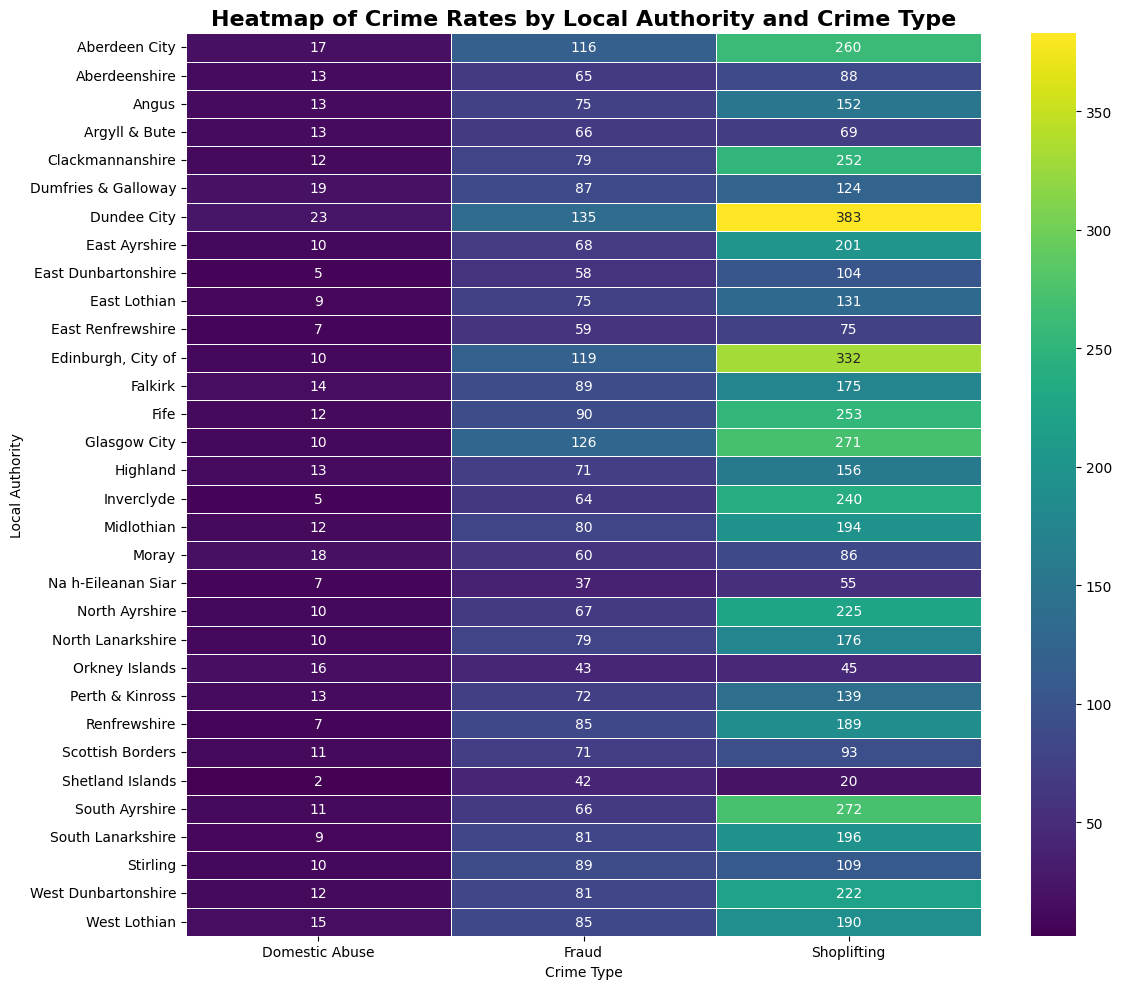

In [7]:
import matplotlib.pyplot as plt # Import the matplotlib.pyplot module for creating visualisations
import seaborn as sns # Import the seaborn library for statistical data visualisation based on matplotlib

# Create Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    crime_pivot.set_index('Local Authority')[crime_features],
    cmap='viridis', # Use colorblind-accessible palette
    annot=True, # Annotate each cell with the numeric value
    fmt='.0f', # Format annotations as whole numbers
    linewidths=.5 # Add lines between cells for better separation
)
plt.title('Heatmap of Crime Rates by Local Authority and Crime Type', fontsize=16, fontweight='bold')
plt.ylabel('Local Authority')
plt.xlabel('Crime Type')
plt.tight_layout()
plt.show()

Visualised in the yellow tones, shoplifting again is shown as the crime with the highest rates, with Dundee City and the City of Edinburgh being the highest. The lower rates of shoplifting are visualised in the darker navy shades for the Orkney and Shetland Islands. The crime rates for fraud are lesser; the heatmap shows a green blue shade for the local authorities with the highest rates; Dundee City being the highest followed by Glasgow City. The dark navy tones show fraud rates lowest in the Scottish Island areas. Lastly the lowest crime type of domestic abuse has navy blue hues for the highest rates in Dundee City and Dumfries and Galloway, and the lowest rates are in dark purple, almost black hues for the Shetland Islands, Inverclyde and East Dunbartonshire. Unlike the bar chart, its easier to pick out from the heatmap that Inverclyde and East Dunbartonshire in particular as having the lowest rates for domestic abuse.

##### **2.2.5. Top Ten Local Authorities for the Three Crime Types**
Table showing the top ten local authorities for the three crime types.

In [8]:
shoplifting_summary = crime_type_summary[crime_type_summary['Crime type'] == 'Shoplifting'].sort_values(by='Crime Rate', ascending=False).head(10).copy() # Filter for 'Shoplifting' crime type and sort by 'Crime Rate' in descending order
shoplifting_summary['Category'] = 'Shoplifting'

fraud_summary = crime_type_summary[crime_type_summary['Crime type'] == 'Fraud'].sort_values(by='Crime Rate', ascending=False).head(10).copy() # Filter for 'Fraud' crime type and sort by 'Crime Rate' in descending order
fraud_summary['Category'] = 'Fraud'

domestic_abuse_summary = crime_type_summary[crime_type_summary['Crime type'] == 'Domestic Abuse'].sort_values(by='Crime Rate', ascending=False).head(10).copy() # Filter for 'Domestic Abuse' crime type and sort by 'Crime Rate' in descending order
domestic_abuse_summary['Category'] = 'Domestic Abuse'

# Combine all summaries into a single DataFrame, ensuring a continuous index
combined_top_10 = pd.concat([shoplifting_summary, fraud_summary, domestic_abuse_summary], ignore_index=True)

# Reorder columns for better readability
combined_top_10 = combined_top_10[['Category', 'Local Authority', 'Crime type', 'Crime Rate']]

# Calculate the last indices of 'Shoplifting' and 'Fraud' categories AFTER concatenation
shoplifting_last_idx = combined_top_10[combined_top_10['Category'] == 'Shoplifting'].index.max()
fraud_last_idx = combined_top_10[combined_top_10['Category'] == 'Fraud'].index.max()


# Define a styling function to apply different background colors based on 'Category' and add borders
def highlight_categories(row):
    styles = [''] * len(row)
    if row['Category'] == 'Shoplifting':
        styles = ['background-color: #e0ffe0'] * len(row)  # Light green
        if row.name == shoplifting_last_idx: # Add a thick bottom border to the last row of this category
            styles = [s + '; border-bottom: 3px solid black' for s in styles]
    elif row['Category'] == 'Fraud':
        styles = ['background-color: #e0f0ff'] * len(row)  # Light blue
        if row.name == fraud_last_idx: # Add a thick bottom border to the last row of this category
            styles = [s + '; border-bottom: 3px solid black' for s in styles]
    elif row['Category'] == 'Domestic Abuse':
        styles = ['background-color: #fff0e0'] * len(row)  # Light orange
    return styles

display(
    combined_top_10.style.hide(axis='index')
    .format({'Crime Rate': '{:.0f}'})
    .apply(highlight_categories, axis=1) # Apply row-wise styling
    .set_caption('Top 10 Local Authorities for Shoplifting, Fraud, and Domestic Abuse')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)

Category,Local Authority,Crime type,Crime Rate
Shoplifting,Dundee City,Shoplifting,383
Shoplifting,"Edinburgh, City of",Shoplifting,332
Shoplifting,South Ayrshire,Shoplifting,272
Shoplifting,Glasgow City,Shoplifting,271
Shoplifting,Aberdeen City,Shoplifting,260
Shoplifting,Fife,Shoplifting,253
Shoplifting,Clackmannanshire,Shoplifting,252
Shoplifting,Inverclyde,Shoplifting,240
Shoplifting,North Ayrshire,Shoplifting,225
Shoplifting,West Dunbartonshire,Shoplifting,222


The clear front runner for the highest level of crime rates is Dundee City for all three crime types. Shoplifting also appears to be an issue in the City of Edinburgh, Glasgow City and South Ayrshire. Fraud has high levels across the major cities in Scotland; Dundee, Edinburgh, Glasgow and Aberdeen. Domestic abuse has high levels in Moray and Orkney, as well as in bigger more populated areas such as Dundee, Dumfries and Galloway and Aberdeen. Surprisingly although they are move heavily populated areas; Glasgow City and Edinburgh City do not appear in the top ten local authority list for rates of domestic abuse.

##### **2.2.6. Distribution Plots/ Boxplots of Crime Rates**
Distribution plots for each crime type will be created help to visualise the spread, central tendency, and any outliers in the crime rates across the various Local Authorities. This gives a clearer picture of the data's characteristics.


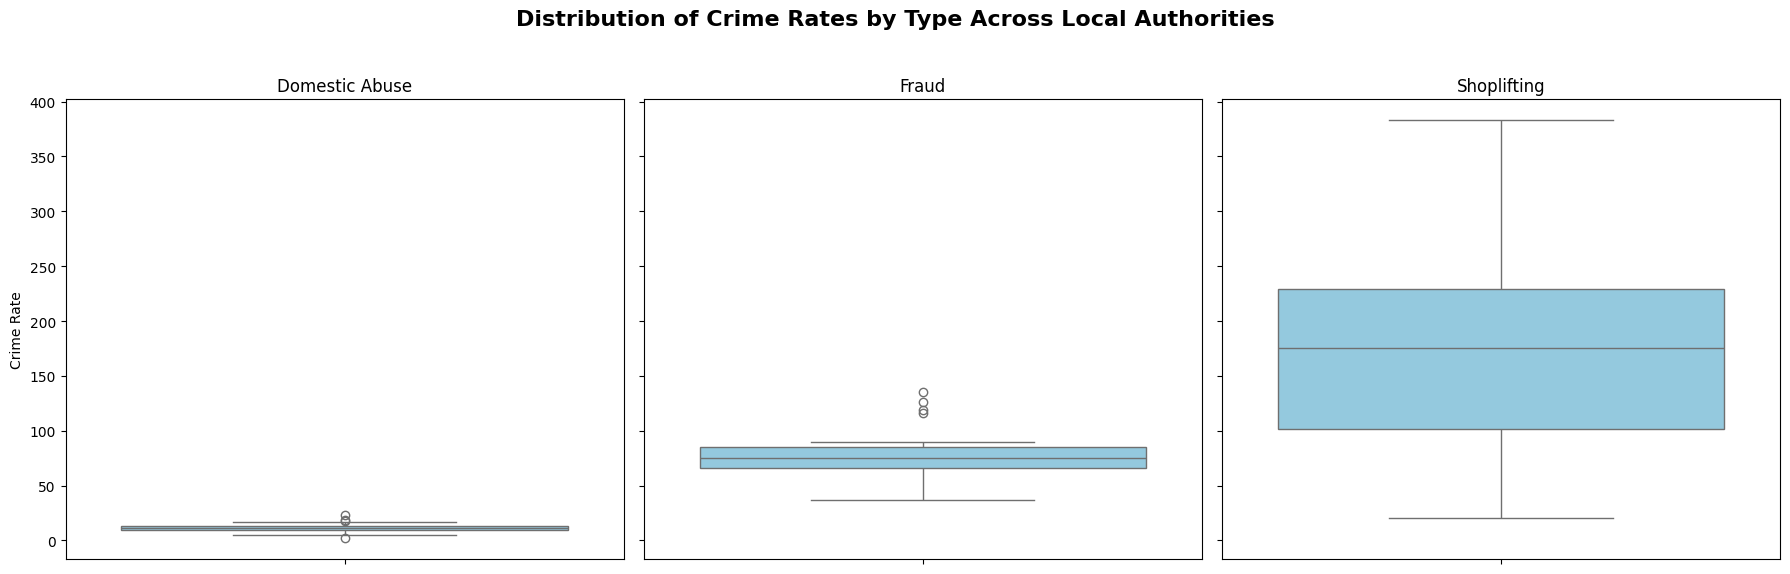

In [9]:
# Create Distribution Plots of Crime Rates
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Set the main title.
fig.suptitle('Distribution of Crime Rates by Type Across Local Authorities', fontsize=16, fontweight='bold', ha='center')

# Loop through each crime feature to create a box plot for each.
# enumerate(crime_features) provides both an index (i) and the feature name.
for i, feature in enumerate(crime_features):
    # Create a box plot for the current crime feature on its respective subplot (axes[i]).
    # y=crime_pivot[feature] specifies the data to be plotted on the y-axis.
    # color='skyblue' sets the color of the box plots.
    sns.boxplot(y=crime_pivot[feature], ax=axes[i], color='skyblue')

    # Set the title for the current subplot to be the name of the crime feature.
    axes[i].set_title(feature)

    # Set the y-axis label for the current subplot.
    axes[i].set_ylabel('Crime Rate')

    # Remove the x-axis label as it's not needed for vertical box plots.
    axes[i].set_xlabel('')

# Adjust layout to prevent labels and titles from overlapping.
# rect=[0, 0.03, 1, 0.95] adjusts the padding around the subplots for the suptitle.
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Display the generated figure with all the box plots.
plt.show()

The three boxplots provide a clear visual representation of the distribution of crime rates for Shoplifting, Fraud, and Domestic Abuse across local authorities.
Shoplifting shows the highest overall rates, with a median around 175.5, indicating that half of the local authorities have shoplifting rates above this value. The range is also quite broad, from a minimum of 20 to a maximum of 383, suggesting significant variability across Scotland. Fraud rates are considerably lower than shoplifting, with a median of 75.0. The main body of data (between Q1 and Q3) ranges from 65.75 to 85.50. However, there are notable outliers on the higher end, with several local authorities having fraud rates above 115.125. The minimum rate is 37. Domestic Abuse has the smallest rates among the three, with a median of 11.5. Its distribution ranges from 2 to 23, so there is less variability across local authorities compared to the other two crime types.


##### **2.2.7. Correlation Matrix of Crime Features**

The correlation matrix shows how strongly each pair of variables is related to each other.

,Domestic Abuse,Fraud,Shoplifting
Domestic Abuse,1.000,0.451,0.275
Fraud,0.451,1.000,0.783
Shoplifting,0.275,0.783,1.000


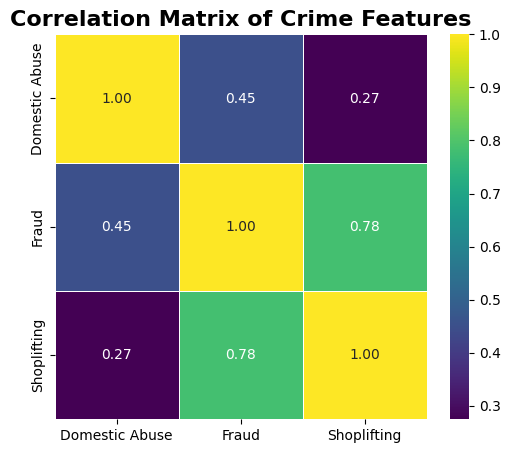

In [10]:
# Calculate the correlation matrix
correlation_matrix = crime_pivot[crime_features].corr()

# Display the correlation matrix with bold and centered caption
print("\n")
display(
    correlation_matrix.style
    .set_caption('<b>Correlation Matrix of Crime Features</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
    .format('{:.3f}') # Format to 3 decimal places
)

print("\n")

# Visualise the correlation matrix with a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='viridis', # Changed colormap to 'viridis' to make it colour blind accessible
    fmt='.2f',
    linewidths=.5
)
plt.title('Correlation Matrix of Crime Features', fontsize=16, fontweight='bold', ha='center')
plt.show()

Both the table and the correlation matrix show that there is a strong positive correlation between fraud and shoplifting (0.78), meaning that local authorities that have high rates of shoplifting appear to have high rates of fraud. Domestic abuse has a moderate positive correlation with fraud (0.45) and a weaker positive correlation with shoplifting (0.27), so there is some relationship, but not as strong as the one between fraud and shoplifting. These results suggest that the strong correlation between fraud and shoplifting and the moderate one between domestic abuse and fraud indicates that the features are not entirely independent. A clustering algorithm will use these relationships to group local authorities to better interpret the resulting clusters.

#### **2.3 Feature Engineering and Unsupervised Learning (K-Means Clustering) on absolute crime rate features**
The data is in the correct wide format, therefore K-Means clustering will be applied to group similar local authorities based on their crime patterns for the three crime types. Data will be scaled, the optimal number of clusters will be found using the Elbow Method, K-Means Clustering perfomed and clusters assigned, then visuals created in bar charts, heatmaps, boxplots and descriptive statistic tables.


##### **2.3.1. Data Preparation: Scaling**

Scaling the data is required before applying K-Means, as the algorithm is distance-based and unscaled features with larger values might disproportionately influence the distance calculations.

In [11]:
from sklearn.preprocessing import StandardScaler # Import StandardScaler for feature scaling
from sklearn.cluster import KMeans # Import KMeans for clustering

# Identify the columns for clustering (crime types)
crime_features = ['Domestic Abuse', 'Fraud', 'Shoplifting']
X_clustering = crime_pivot[crime_features]

# Scale the data
# StandardScaler transforms data to have a mean of 0 and a standard deviation of 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Display the first 5 rows of the scaled data to show the transformation
display(
    pd.DataFrame(X_scaled, columns=crime_features).head().style.hide(axis='index')
    .set_caption('<b>Scaled data for clustering (first 5 rows)</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
    .format('{:.3f}')
)

Domestic Abuse,Fraud,Shoplifting
1.299,1.745,1.046
0.354,-0.567,-0.979
0.354,-0.113,-0.225
0.354,-0.521,-1.202
0.118,0.068,0.951


Data is now scaled for clustering using standardisation (Z-score Scaling) to transform the data. The mean of each crime type is subtracted from every data point then its divided by the standard deviation of that crime type. Each crime type now has a mean of 0 and standard deviation of 1. The positive values indicate that the local authority's crime rate for that type is above average whereas a negative value indicates that the local authority's crime rate for that type is below average.

##### **2.3.2. Determine Optimal Number of Clusters (Elbow Method)**

The elbow method will be used to help decide on a suitable number of clusters (k). This method involves plotting the inertia (within-cluster sum of squares) for different values of k, and selecting the k where the decrease in inertia begins to slow down, showing an 'elbow' in the plot.

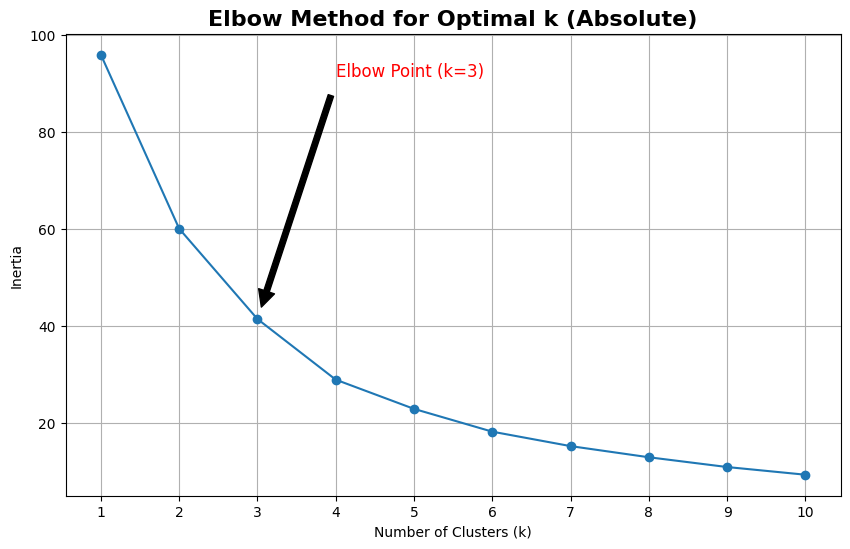

In [12]:
inertia = [] # Create an empty list to store the inertia values for each k
k_range = range(1, 11) # Define the range of k values (number of clusters) to test, from 1 to 10

# Loop through each k in the defined range
for k in k_range:
    # Initialise KMeans model with the current k
    # and n_init=10 to explicitly set the number of initialisations (to suppress a future warning).
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Fit the KMeans model to the scaled data
    kmeans.fit(X_scaled)
    # Append the inertia (sum of squared distances of samples to their closest cluster center) to the list
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
fig = plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o') # Plot inertia against k, with circular markers
plt.xlabel('Number of Clusters (k)') # Label for the x-axis
plt.ylabel('Inertia') # Label for the y-axis
plt.title('Elbow Method for Optimal k (Absolute)', fontsize=16, fontweight='bold') # Title of the plot with custom font size and weight
plt.xticks(k_range) # Ensure x-axis ticks correspond to the k values tested
plt.grid(True) # Add a grid to the plot for better readability

# Add annotation for the elbow point at k=3
plt.annotate('Elbow Point (k=3)', xy=(3, inertia[2]), xytext=(4, inertia[2] + 50), # Adjust xytext for positioning
             arrowprops=dict(facecolor='black', shrink=0.05), # Arrow properties
             fontsize=12, color='red') # Text properties

plt.show() # Display the plot

Based on the elbow plot, the appropriate 'k' (the number of clusters) is determined. As it starts to decrease and flatten out from 3, k=3 is selected.






##### 2.3.3. Perform K-Means Clustering and Assign Clusters

The K-Means with k=3 will be applied and the cluster labels added back to the 'crime_pivot' DataFrame.

In [14]:
# Define the number of clusters (k) based on the Elbow Method
k = 3
# Initialise the KMeans model with k=3 and a random state for reproducibility
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
# Fit the KMeans model to the scaled data and predict cluster assignments
# Then, add these cluster assignments as a new 'Cluster' column to the crime_pivot DataFrame
crime_pivot['Cluster'] = kmeans_model.fit_predict(X_scaled)

# Display the first few rows of the DataFrame, including the new 'Cluster' column
# The table is styled to hide the index, format crime counts as whole numbers, and set a bold, centered caption.
display(
    crime_pivot.head().style.hide(axis='index').format({col: '{:.0f}' for col in crime_features})
    .set_caption(f"DataFrame with {k} clusters (first 5 rows)")
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)


Local Authority,Domestic Abuse,Fraud,Shoplifting,Cluster
Aberdeen City,17,116,260,2
Aberdeenshire,13,65,88,0
Angus,13,75,152,1
Argyll & Bute,13,66,69,0
Clackmannanshire,12,79,252,1


##### **2.3.4. Local Authorities by Cluster**

To see which local authorities fall into each of the k=3 clusters, we can group the crime_pivot DataFrame by the newly assigned 'Cluster' column. This provides a clear list of local authorities for each cluster.

In [15]:
from IPython.display import HTML

html_tables = []
# Group the DataFrame by 'Cluster' and display the 'Local Authority' in each cluster
for cluster_id in sorted(crime_pivot['Cluster'].unique()):
    # Filter the DataFrame for the current cluster and create a new DataFrame
    local_authorities_in_cluster_df = crime_pivot[crime_pivot['Cluster'] == cluster_id][['Local Authority']].copy()

    # Generate the styled HTML for each table
    styled_table_html = local_authorities_in_cluster_df.style.hide(axis='index')\
        .set_caption(f"<b>Local Authorities in Cluster {cluster_id}</b>")\
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': '', 'props': [('border-collapse', 'collapse'), ('margin', '10px')]}
        ])\
        .to_html()
    html_tables.append(f"<div style='display: inline-block; vertical-align: top; margin-right: 20px;'>{styled_table_html}</div>")

# Combine all HTML tables into a single flex container for side-by-side display
combined_html = "".join(html_tables)
display(HTML(f"<div style='display: flex; justify-content: flex-start;'>{combined_html}</div>"))

Local Authority
Aberdeenshire
Argyll & Bute
East Dunbartonshire
East Renfrewshire
Moray
Na h-Eileanan Siar
Orkney Islands
Scottish Borders
Shetland Islands
Local Authority


Cluster 0 has the lowest crime rates for the three crime types, cluster 1 has more moderate crime rates and cluster 2 has the highest crime rates. The major Scottish cities all feature in the highest crime rate areas and the Scottish Islands are all featured as the lowest crime rate areas. Aberdeenshire area is in the lowest cluster, however its city is in the highest.

##### **2.3.5. Bar Chart of Average Crime rates per Cluster**

Bar chart showing the average crime rates per cluster.

In [16]:
# Calculate the mean crime rate for each crime type per cluster
# .reset_index() converts the grouped output back into a DataFrame.
cluster_means = crime_pivot.groupby('Cluster')[crime_features].mean().reset_index()

# Melt the cluster_means DataFrame for easier plotting with Plotly Express
# This transforms the 'cluster_means' DataFrame from a wide format (crime types as columns) to a long format (crime types in a single 'Crime Type' column and their values in 'Average Crime Rate').
cluster_means_melted = cluster_means.melt(
    id_vars='Cluster', # Columns to keep as identifier variables
    value_vars=crime_features, # Columns to unpivot (crime types)
    var_name='Crime Type', # New column name for the unpivoted column headers
    value_name='Average Crime Rate' # New column name for the unpivoted values
)

# Create a grouped bar chart to visualise cluster profiles
fig = px.bar(
    cluster_means_melted,
    x='Crime Type',
    y='Average Crime Rate',
    color='Crime Type',
    facet_col='Cluster',
    facet_col_wrap=2, # Adjust as needed for number of clusters
    title='Average Crime Rates by Crime Type within Each Cluster',
    labels={'Average Crime Rate': 'Average Crime Rate'},
    height=500,
    width=900,
    color_discrete_sequence=px.colors.qualitative.D3 # Use a colorblind-friendly palette
)

# Update the layout of the figure for better readability and presentation
fig.update_layout(xaxis_title='Crime Type', yaxis_title='Average Crime Rate', title_font=dict(color='black', weight='bold'), title_x=0.5)
fig.show()

# Display the 'cluster_means' DataFrame with enhanced styling
display(
    cluster_means.style.hide(axis='index').format({col: '{:.2f}' for col in crime_features})
    .set_caption('<b>Average Crime Rates for Each Cluster</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)


Cluster,Domestic Abuse,Fraud,Shoplifting
0,10.22,55.67,70.56
1,11.37,78.05,189.26
2,15.00,124.00,311.50


Cluster 0 shows the lowest average crime rates, cluster 1 is the intermediate average crime rates and cluster 2 is the highest average crime rates for all three crime types. Clusters 1 and 2 clearly show again the high rates for shoplifting. Local authorities in cluster 2 will have the highest incidences of all of the crime types. The range between the clusters for fraud and shoplifting is quite apparent, however there is not a huge difference in the domestic abuse rates over the clusters.

##### **2.3.6. Descriptive Statistics of the three crime types by Cluster**

To further understand the characteristics of each cluster, we can look at the descriptive statistics for each of the three crime types within each cluster.



In [17]:
# Iterate through each crime feature to generate descriptive statistics per cluster
for feature in crime_features:
    # Group the crime_pivot DataFrame by 'Cluster' and calculate descriptive statistics for the current feature
    cluster_descriptive_stats = crime_pivot.groupby('Cluster')[feature].describe()

    # Display the descriptive statistics table with consistent styling
    display(
        cluster_descriptive_stats.style
        .set_caption(f"<b>Descriptive Statistics for {feature} by Cluster</b>") # Set bold and centered caption
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
        ])
        .format('{:.3f}') # Format numbers to 3 decimal places for consistency with other stats
    )
    print('\n')


,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,9.000,10.222,5.310,2.000,7.000,11.000,13.000,18.000
1,19.000,11.368,3.041,5.000,10.000,12.000,13.000,19.000
2,4.000,15.000,6.272,10.000,10.000,13.500,18.500,23.000


,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,9.000,55.667,12.042,37.000,43.000,59.000,65.000,71.000
1,19.000,78.053,8.343,64.000,71.500,79.000,85.000,90.000
2,4.000,124.000,8.446,116.000,118.250,122.500,128.250,135.000


,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,9.000,70.556,26.548,20.000,55.000,75.000,88.000,104.000
1,19.000,189.263,46.827,109.000,154.000,190.000,223.500,272.000
2,4.000,311.500,57.228,260.000,268.250,301.500,344.750,383.000


Summary of what the descriptive statistics indicate:

Cluster 0: Generally has the lowest crime rates across all three categories, with mean values for Domestic Abuse around 10, Fraud around 55, and Shoplifting around 70. The maximum values within this cluster are also considerably lower than in other clusters.
Cluster 1: Shows moderate crime rates. For instance, the mean for Shoplifting jumps significantly to about 189, compared to Cluster 0, while Domestic Abuse and Fraud means are also higher than Cluster 0 but lower than Cluster 2.
Cluster 2: Exhibits the highest crime rates for all three features, with mean values for Domestic Abuse at 15, Fraud at 124, and Shoplifting at 311. This cluster represents local authorities with the highest incidences of these specific crimes.

##### **2.3.7. Heatmap of Average Crime Rates by Cluster**

To visually summarise the characteristics of each cluster, we can create a heatmap using the cluster_means DataFrame. This plot will clearly show which crime types are more prevalent in certain clusters on average.

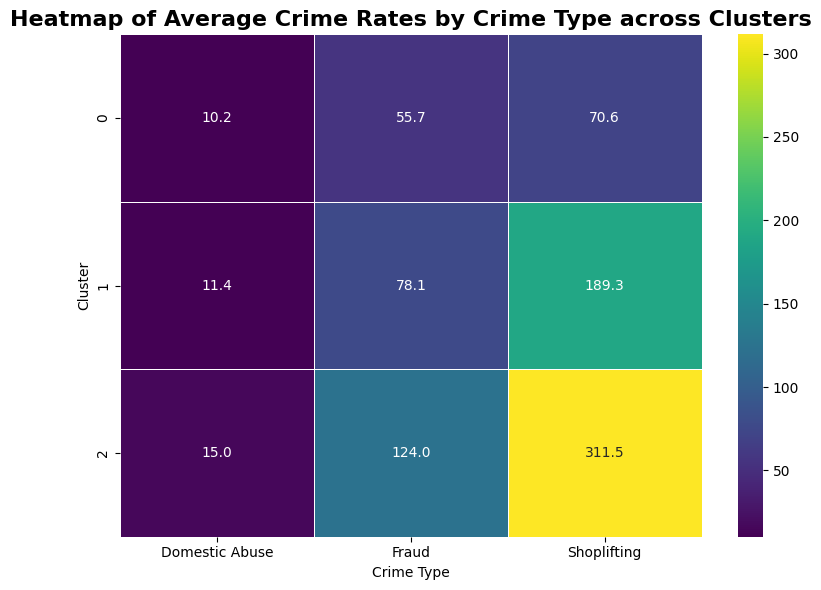

In [18]:
# Create a figure and axes for the heatmap
plt.figure(figsize=(8, 6))

# Generate the heatmap using the mean crime counts per cluster
sns.heatmap(
    cluster_means.set_index('Cluster')[crime_features],
    cmap='viridis', # Use an accessibile palette
    annot=True, # Annotate each cell with the numeric value
    fmt='.1f', # Format to one decimal place for means
    linewidths=.5 # Add lines between cells for better separation
)

# Set the title of the heatmap with bold, larger font, and center alignment
plt.title('Heatmap of Average Crime Rates by Crime Type across Clusters', fontsize=16, fontweight='bold', ha='center')

# Set the y-axis label
plt.ylabel('Cluster')
# Set the x-axis label
plt.xlabel('Crime Type')
# Adjust layout to prevent labels from being cut off
plt.tight_layout()
# Display the plot
plt.show()


This heatmap provides a clear visual summary of the average crime rates for the three crime types across the three clusters. Shoplifting stands out with a yellow hue as having the highest rate of increase at 311.5 in cluster 2, and also has the highest rates across the other two clusters. Domestic abuse has the lowest average rates of increase across all three clusters and is displayed in the navy tones. Fraud rates increase across all three clusters on a steady rate from cluster 0 to 2.

##### **2.3.8. Distribution of Crime Rates Within Each Cluster (Box Plots)**

To further understand the variability of crime rates within each cluster for each crime type, box plots will be created. This helps to see the spread, central tendency, and any outliers for the local authorities belonging to a particular cluster.

In [19]:
# Melt the crime_pivot DataFrame to facilitate plotting distributions by cluster and crime type
crime_pivot_melted = crime_pivot.melt(
    id_vars=['Local Authority', 'Cluster'], # Columns to keep as identifier variables
    value_vars=crime_features, # Columns to unpivot (crime types)
    var_name='Crime Type', # New column name for the unpivoted column headers
    value_name='Crime Rate' # New column name for the unpivoted values
)

# Ensure the 'Cluster' column is categorical with the desired order
cluster_order = sorted(crime_pivot_melted['Cluster'].unique())
crime_pivot_melted['Cluster'] = pd.Categorical(crime_pivot_melted['Cluster'], categories=cluster_order, ordered=True)

# Create box plots to visualise the distribution of crime counts within each cluster
fig = px.box(
    crime_pivot_melted,
    x='Crime Type',
    y='Crime Rate',
    color='Cluster',
    facet_col='Cluster',
    facet_col_wrap=2, # Adjust as needed for number of clusters
    title='Distribution of Crime Rates by Type Within Each Cluster',
    labels={'Crime Rate': 'Crime Rate', 'Crime Type': 'Crime Type'},
    height=500,
    width=900,
    category_orders={'Cluster': cluster_order} # Ensure facets are ordered 0, 1, 2
)

# Update the layout of the figure for better readability and presentation
#   - xaxis_title, yaxis_title: Set the titles for the x and y axes.
#   - title_font: Customize the font properties (color, weight, size) of the main title).
#   - title_x: Position the title horizontally (0.5 for center alignment).
fig.update_layout(
    xaxis_title='Crime Type',
    yaxis_title='Crime Rate',
    title_font=dict(color='black', weight='bold', size=20), # Make title bold, black, and larger
    title_x=0.5 # Center the title
)
fig.show()


The box plots provide a more detailed view of the variability of crime rates within each cluster for each crime type. They show the spread of the data, the median values, and any potential outliers for the local authorities belonging to a particular cluster.

Cluster 0 has the lowest crime rates. Domestic abuse shows a very tight distribution, with median around 10. There are no significant outliers, indicating consistency among local authorities in this cluster. The rates are concentrated at the lower end of the scale.
Fraud is also tightly distributed, with median values around 50-60 with little variability. No clear outliers are present, confirming reseaonably low fraud rates.
Shoplifting rates are low in the cluster in Cluster 0.

Cluster 1 has intermediate crime rates. Domestic Abuse has a  median that is slightly higher than Cluster 0, around 11-12. The distribution is still relatively tight, but a few minor outliers might appear.
Fraud exhibits a median in the 70-80 range. The box seems to be a bit wider than in Cluster 0, indicating more variability. There are typically a few outliers on the higher end, showing that some local authorities in this cluster have higher fraud rates than others in the same cluster.
Shoplifting shows a significantly higher median, often in the 150-200 range. The box is notably wider, indicating a greater spread of shoplifting rates. This cluster tends to have more outliers on the higher side, highlighting specific local authorities with elevated shoplifting challenges.

Cluster 2 has the highest crime rates. Domestic Abuse has the highest median here at around 15. While still lower than other crime types, the box might be slightly wider than in Cluster 0, with a few upward outliers, indicating a higher baseline of domestic abuse across these areas.
Fraud in this cluster displays the highest median for fraud, often above 100. The distribution is broad, and it typically features several significant outliers at the top, signifying local authorities with exceptionally high fraud rates compared to the rest.
Shoplifting clearly stands out with the highest median, frequently above 300. The box is very wide, and numerous significant outliers are present, indicating a high degree of variability and extreme shoplifting rates in some local authorities within this cluster. This confirms that these areas face the most severe shoplifting challenges.

This detailed breakdown of the box plots confirms the distinct crime profiles of each cluster, revealing not just average rates but also the consistency and presence of outliers within each grouping.

#### **2.4 Feature Engineering and Unsupervised Learning (K-Means Clustering) with Year-on-Year (YoY) Percentage Change**

To cluster local authorities based on how fast crime is growing rather than just absolute volumes, Year-on-Year (YoY) Percentage Change for the three crime types will be calculated. These YoY changes will then be used as features for a new K-Means clustering analysis.
 Data will be scaled for YoY features, the optimal number of clusters will be found using the Elbow Method, K-Means Clustering perfomed and clusters assigned, then visuals created in bar charts, heatmaps, boxplots, correlation matrix, and descriptive statistic tables.

In [20]:
# Define the crime types to include for YoY calculation
yoy_crime_types = ['Domestic Abuse', 'Fraud', 'Shoplifting']

# Filter for relevant crime types
df_yoy = df_long[df_long['Crime type'].isin(yoy_crime_types)].copy()

# Create a numeric year column from the 'Year' string for sorting
df_yoy['Year_numeric'] = df_yoy['Year'].apply(lambda x: int(x.split('-')[0]))

# Sort data to ensure correct YoY calculation
df_yoy = df_yoy.sort_values(by=['Local Authority', 'Crime type', 'Year_numeric'])

# Pivot to get 'Crime Rate' for each 'Year' as columns, for each Local Authority and Crime type
pivot_for_yoy = df_yoy.pivot_table(
    index=['Local Authority', 'Crime type'],
    columns='Year_numeric',
    values='Crime Rate',
    observed=False # Add observed=False to suppress FutureWarning
)

# Calculate percentage change year-on-year. Fill NaN from first year with 0.
yoy_changes = pivot_for_yoy.pct_change(axis=1).fillna(0) * 100

# Most recent YoY change for clustering.
latest_yoy_column = yoy_changes.columns[-1]

# Extract the latest YoY change and reset index
yoy_crime_pivot_long = yoy_changes[latest_yoy_column].reset_index()
yoy_crime_pivot_long = yoy_crime_pivot_long.rename(columns={latest_yoy_column: 'Latest_YoY_Change'})

# Pivot again to get crime types as columns for the final yoy_crime_pivot DataFrame
yoy_crime_pivot = yoy_crime_pivot_long.pivot_table(
    index='Local Authority',
    columns='Crime type',
    values='Latest_YoY_Change',
    observed=False # Add observed=False to suppress FutureWarning
).reset_index()

# Rename columns to reflect YoY change
yoy_crime_pivot.columns = ['Local Authority'] + [f'{col} YoY Change' for col in yoy_crime_types]
yoy_crime_pivot.columns.name = None # Remove the column name 'Crime type'

# Fill any NaN values that might result from pct_change (e.g., if a crime type had 0 for all years
yoy_crime_pivot.fillna(0, inplace=True)


display(
    yoy_crime_pivot.head(10).style.hide(axis='index')
    .set_caption('<b>Year-on-Year Crime Rate Changes (First 10 Rows)</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
    .format({col: '{:.2f}' for col in yoy_crime_pivot.columns if col != 'Local Authority'})
)

Local Authority,Domestic Abuse YoY Change,Fraud YoY Change,Shoplifting YoY Change
Aberdeen City,0.00,-12.50,-4.35
Aberdeenshire,25.00,-9.52,25.00
Angus,0.00,-14.29,36.73
Argyll & Bute,100.00,0.00,13.04
Clackmannanshire,-40.00,-37.93,-1.06
Dumfries & Galloway,14.29,3.57,-9.30
Dundee City,12.50,-13.33,-13.10
East Ayrshire,33.33,-8.33,11.59
East Dunbartonshire,0.00,-10.00,14.71
East Lothian,33.33,-15.38,1.92


For each of the local authorities, the percentage in which the crime rates for the three crime types increase or decrease are displayed. Argyll and Bute has a 100% increase Year-on-Year crime rate increase whereas the rate has decreased by 40% in Clackmannanshire. Fraud appears to be decreasing across the local authorities displayed; with the exception of the 3.57% increase in Dumfries and Galloway. Shoplifting has a mixture of increasing and decreasing percentages across the first ten local authorities listed.

##### **2.4.1. Data Preparation: Scaling YoY Features**

As with the absolute crime counts, the YoY percentage scaling is required to change data before applying K-Means. This ensures that features with different ranges do not disproportionately influence the distance calculations.

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Identify the new columns for clustering (YoY change features)
yoy_crime_features = [col for col in yoy_crime_pivot.columns if 'YoY Change' in col]
X_yoy_clustering = yoy_crime_pivot[yoy_crime_features]

# Scale the YoY data
yoy_scaler = StandardScaler()
X_yoy_scaled = yoy_scaler.fit_transform(X_yoy_clustering)

display(
    pd.DataFrame(X_yoy_scaled, columns=yoy_crime_features, index=yoy_crime_pivot['Local Authority']).head().style
    .set_caption('<b>Scaled YoY data for clustering (first 5 rows)</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
    .format('{:.3f}')
)

,Domestic Abuse YoY Change,Fraud YoY Change,Shoplifting YoY Change
Local Authority,,,
Aberdeen City,-0.691,-0.244,-0.739
Aberdeenshire,-0.296,-0.024,0.742
Angus,-0.691,-0.376,1.334
Argyll & Bute,0.891,0.679,0.138
Clackmannanshire,-1.324,-2.122,-0.573


Standardisation (Z-score scaling) is applied to the YoY change features using StandardScaler. For each crime type, the mean is subtracted and the result is divided by the standard deviation, producing values with mean 0 and standard deviation 1. Positive values indicate above‑average YoY increases, while negative values indicate below‑average changes.

##### **2.4.2. Determine Optimal Number of Clusters (Elbow Method) for YoY Data**

Reapply the elbow method to help decide on a suitable number of clusters 'k' for the YoY percentage change data.

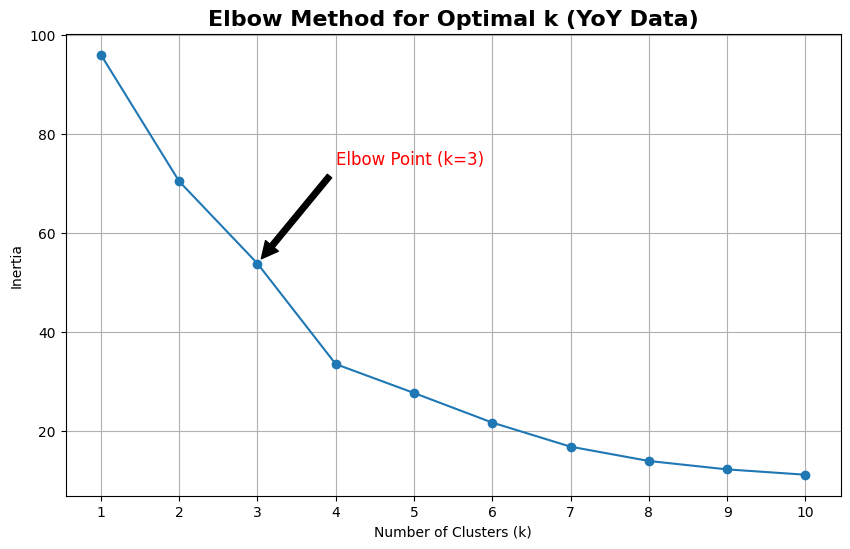

In [24]:
from sklearn.cluster import KMeans # Import KMeans for clustering

inertia_yoy = [] # Initialise an empty list to store the inertia values for each k
k_range_yoy = range(1, 11) # Define the range of k values (number of clusters) to test, from 1 to 10

# Loop through each k in the defined range
for k in k_range_yoy:
    kmeans_yoy = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_yoy.fit(X_yoy_scaled)
    inertia_yoy.append(kmeans_yoy.inertia_)

# Plot the elbow curve for YoY data
fig = plt.figure(figsize=(10, 6))
plt.plot(k_range_yoy, inertia_yoy, marker='o') # Plot inertia against k, with circular markers
plt.xlabel('Number of Clusters (k)') # Label for the x-axis
plt.ylabel('Inertia') # Label for the y-axis
plt.title('Elbow Method for Optimal k (YoY Data)', fontsize=16, fontweight='bold', ha='center') # Title of the plot with custom font size, weight, and center alignment
plt.xticks(k_range_yoy) # Ensure x-axis ticks correspond to the k values tested
plt.grid(True) # Add a grid to the plot for better readability

# Add annotation for the elbow point at k=3
plt.annotate('Elbow Point (k=3)', xy=(3, inertia_yoy[2]), xytext=(4, inertia_yoy[2] + 20), # Adjust xytext for positioning
             arrowprops=dict(facecolor='black', shrink=0.05), # Arrow properties
             fontsize=12, color='red') # Text properties

plt.show() # Display the plot

Based on the elbow plot for YoY data, k=3 seems appropriate as before.



##### **2.4.3. Perform K-Means Clustering and Assign Clusters (YoY Data)**

Apply chose k=3 to the scaled YoY data and add the cluster labels back to yoy_crime_pivot DataFrame.

In [25]:
# Perform K-Means clustering with k=3 (or the optimal k from the elbow method for YoY)
k_yoy = 3
kmeans_yoy_model = KMeans(n_clusters=k_yoy, random_state=42, n_init=10)
yoy_crime_pivot['Cluster_YoY'] = kmeans_yoy_model.fit_predict(X_yoy_scaled)

# Display the DataFrame with new cluster assignments
display(
    yoy_crime_pivot.head().style.hide(axis='index')
    .set_caption(f"<b>DataFrame with {k_yoy} clusters based on YoY Change (first 5 rows)</b>")
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
    .format({col: '{:.3f}' for col in yoy_crime_features})
)

Local Authority,Domestic Abuse YoY Change,Fraud YoY Change,Shoplifting YoY Change,Cluster_YoY
Aberdeen City,0.000,-12.500,-4.348,0
Aberdeenshire,25.000,-9.524,25.000,1
Angus,0.000,-14.286,36.735,1
Argyll & Bute,100.000,0.000,13.043,0
Clackmannanshire,-40.000,-37.931,-1.064,1


The Year-on-Year percentage change for the three crime types with the cluster allocation number.
These values, such as -12.500 for Fraud YoY Change in the first row, indicate a decrease of 12.5% in Fraud for 'Aberdeen City' compared to the previous year. Positive values indicate an increase such as in Angus with an increase of 25% and most notably in Argyll and Bute where the increase for domestic abuse has been 100%.


##### **2.4.4. Local Authorities by Cluster (YoY)**

To explicitly see which local authorities fall into each of the k=3 clusters based on Year-on-Year change, the dataferame yoy_crime_pivot has a newly assigned 'Cluster_YoY' column. This provides a clear list of members for each YoY cluster.

In [26]:
from IPython.display import HTML

html_tables_yoy = []
# Group the DataFrame by 'Cluster_YoY' and display the 'Local Authority' in each cluster
for cluster_id in sorted(yoy_crime_pivot['Cluster_YoY'].unique()):
    # Filter the DataFrame for the current cluster and create a new DataFrame
    local_authorities_in_cluster_yoy_df = yoy_crime_pivot[yoy_crime_pivot['Cluster_YoY'] == cluster_id][['Local Authority']].copy()

    # Generate the styled HTML for each table
    styled_table_html_yoy = local_authorities_in_cluster_yoy_df.style.hide(axis='index')\
        .set_caption(f"<b>Local Authorities in YoY Cluster {cluster_id}</b>")\
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': '', 'props': [('border-collapse', 'collapse'), ('margin', '10px')]}
        ])\
        .to_html()
    html_tables_yoy.append(f"<div style='display: inline-block; vertical-align: top; margin-right: 20px;'>{styled_table_html_yoy}</div>")

# Combine all HTML tables into a single flex container for side-by-side display
combined_html_yoy = "".join(html_tables_yoy)
display(HTML(f"<div style='display: flex; justify-content: flex-start;'>{combined_html_yoy}</div>"))

Local Authority
Aberdeen City
Argyll & Bute
Dumfries & Galloway
Dundee City
East Lothian
Falkirk
Highland
Na h-Eileanan Siar
North Ayrshire
North Lanarkshire


The clustering using YoY trends has changed the clusters significantly from the cluster allocations for the absolute crime rates. The highest crime rates YoY in cluster 2 are now East Renfrewshire and Inverclyde. The major Scottish cities have been moved back into cluster 0, suggesting different growth trends for these areas.

##### **2.4.5. Bar Chart of Average Crime rates per Cluster (YoY)**

Bar chart of the average crime rates per cluster based on YoY changes.

In [27]:
import plotly.express as px

# Calculate the mean YoY change for each crime type per cluster.
yoy_cluster_means = yoy_crime_pivot.groupby('Cluster_YoY')[yoy_crime_features].mean().reset_index()

# Melt the yoy_cluster_means DataFrame for easier plotting with Plotly Express to transform the 'yoy_cluster_means' DataFrame from a wide format to a long format
yoy_cluster_means_melted = yoy_cluster_means.melt(
    id_vars='Cluster_YoY', # Columns to keep as identifier variables
    value_vars=yoy_crime_features, # Columns to unpivot (YoY features)
    var_name='YoY Crime Type', # New column name for the unpivoted column headers
    value_name='Average YoY Change' # New column name for the unpivoted values
)

# Create a grouped bar chart to visualise cluster profiles based on YoY changes.
fig = px.bar(
    yoy_cluster_means_melted,
    x='YoY Crime Type',
    y='Average YoY Change',
    color='YoY Crime Type',
    facet_col='Cluster_YoY',
    facet_col_wrap=2,
    title='Average YoY Percentage Change by Crime Type within Each Cluster',
    labels={'Average YoY Change': 'Average YoY Change (%)', 'YoY Crime Type': 'Crime Type (YoY)'},
    height=500,
    width=1000
)


fig.update_layout(
    xaxis_title='YoY Crime Type',
    yaxis_title='Average YoY Change (%)',
    title_font=dict(color='black', weight='bold'),
    title_x=0.5
)
fig.show()

print()

display(
    yoy_cluster_means.style.hide(axis='index')
    .set_caption('<b>Average YoY Percentage Changes for Each Cluster</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
    .format({col: '{:.2f}' for col in yoy_crime_features}) # Format to two decimal places for percentages
)


Cluster_YoY,Domestic Abuse YoY Change,Fraud YoY Change,Shoplifting YoY Change
0,38.12,-4.49,-4.14
1,21.78,-12.53,23.56
2,250.00,-19.50,19.13


Across all three clusters (YoY) there is a notable average increase in domestic abuse, especially in Cluster 2. Fraud has decreased in all three clusters. Shoplifting has decreased in cluster 0, but has increased in clusters 1 and 2.

##### **2.4.6. Descriptive Statistics of YoY Features by Cluster**
To further understand the characteristics of each cluster, we can look at the descriptive statistics for each YoY change feature within each cluster.



In [28]:
# Loop through each YoY crime feature to generate and display descriptive statistics per cluster
for feature in yoy_crime_features:
    # Group the 'yoy_crime_pivot' DataFrame by 'Cluster_YoY'and calculate descriptive statistics for the current feature (mean, std, min, max, quartiles).
    yoy_cluster_descriptive_stats = yoy_crime_pivot.groupby('Cluster_YoY')[feature].describe()

    # Display the descriptive statistics table with enhanced styling
    display(
        yoy_cluster_descriptive_stats.style
        .set_caption(f"<b>Descriptive Statistics for {feature} by Cluster</b>") # Set bold and centered caption
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
        ])
        .format('{:.3f}') # Format numbers to 3 decimal places for consistency
    )
    print('\n') # Add a newline after each table for better visual separation

,count,mean,std,min,25%,50%,75%,max
Cluster_YoY,,,,,,,,
0,15.000,38.119,38.453,0.000,6.250,25.000,66.667,100.000
1,15.000,21.778,25.839,-40.000,0.000,33.333,33.333,66.667
2,2.000,250.000,70.711,200.000,225.000,250.000,275.000,300.000


,count,mean,std,min,25%,50%,75%,max
Cluster_YoY,,,,,,,,
0,15.000,-4.486,15.049,-30.769,-14.359,-6.667,0.000,30.000
1,15.000,-12.529,11.783,-37.931,-18.750,-12.903,-5.417,8.000
2,2.000,-19.500,6.364,-24.000,-21.750,-19.500,-17.250,-15.000


,count,mean,std,min,25%,50%,75%,max
Cluster_YoY,,,,,,,,
0,15.000,-4.139,10.393,-28.571,-9.413,-4.348,2.922,13.043
1,15.000,23.562,19.018,-1.064,10.485,23.438,35.299,74.510
2,2.000,19.127,8.306,13.253,16.190,19.127,22.063,25.000


Summary of what the descriptive statistics indicate:

Cluster 0: Mean values for Domestic Abuse increase at around 38%, with decreases for Fraud at around -4.48%, and Shoplifting at around -4.13%.
Cluster 1: Shows mixed to moderate average YoY rates. For instance, the mean for shoplifting jumps significantly to an increase of about 23.562%, compared to Cluster 0's decrease. However, Domestic Abuse (21.78%) and Fraud (-12.53%) show lower average increases/decreases compared to Cluster 0.
Cluster 2: Exhibits the highest average YoY change for domestic abuse, with mean value for Domestic Abuse at a 250% increase, the steepest decrease for Fraud at -19.5% decrease, and a moderate increase for Shoplifting at 19.127% increase.
These statistics reinforce the cluster profiles we observed in the bar chart, providing quantitative evidence for the distinct characteristics of each group of local authorities.

##### **2.4.7. Correlation Matrix of YoY Features**

Correlation matrix of YoY Features. This helps reveal if growth trends in one crime type are associated with growth trends in another.

,Domestic Abuse YoY Change,Fraud YoY Change,Shoplifting YoY Change
Domestic Abuse YoY Change,1.000,-0.004,0.127
Fraud YoY Change,-0.004,1.000,0.220
Shoplifting YoY Change,0.127,0.220,1.000


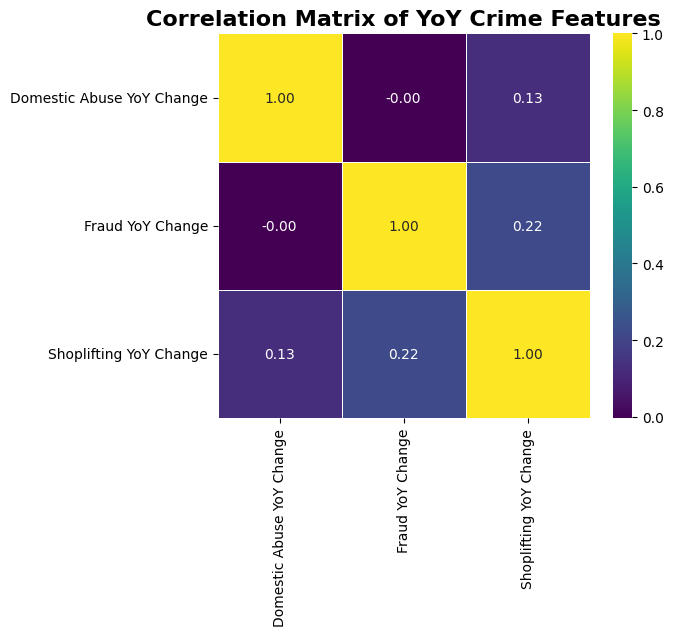

In [29]:
# Calculate the correlation matrix for YoY features
correlation_matrix_yoy = yoy_crime_pivot[yoy_crime_features].corr()

# Display the correlation matrix with bold and centered caption
display(
    correlation_matrix_yoy.style
    .set_caption('<b>Correlation Matrix of YoY Crime Features</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
    .format('{:.3f}') # Format to 3 decimal places
)

print("\n")

# Visualise the correlation matrix with a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    correlation_matrix_yoy,
    annot=True,
    cmap='viridis', # Use a colorblind-accessible colormap
    fmt='.2f',
    linewidths=.5
)
plt.title('Correlation Matrix of YoY Crime Features', fontsize=16, fontweight='bold', ha='center')
plt.show()

The correlation matrix shows no relationships between domestic abuse YoY change and fraud YoY change, indicating no linear relationship in their growth trends. There is a slight positive correlation between shoplifting YoY change and domestic abuse YoY change at 0.13 and for fraud YoY change and shoplifting YoY change at 0.22. Unlike absolute crime rates, the changes in crime types YoY are largely independent or very weakly related. Therefore, factors driving a change in a crime types growth does not significantly impact the growth of another.

##### **2.4.8. Heatmap of Average YoY Change by Cluster**

This heatmap provides a quick visual summary of how the average YoY percentage changes for the three crime types across the newly formed clusters, highlighting which crime types are growing fastest (or declining) in each cluster.

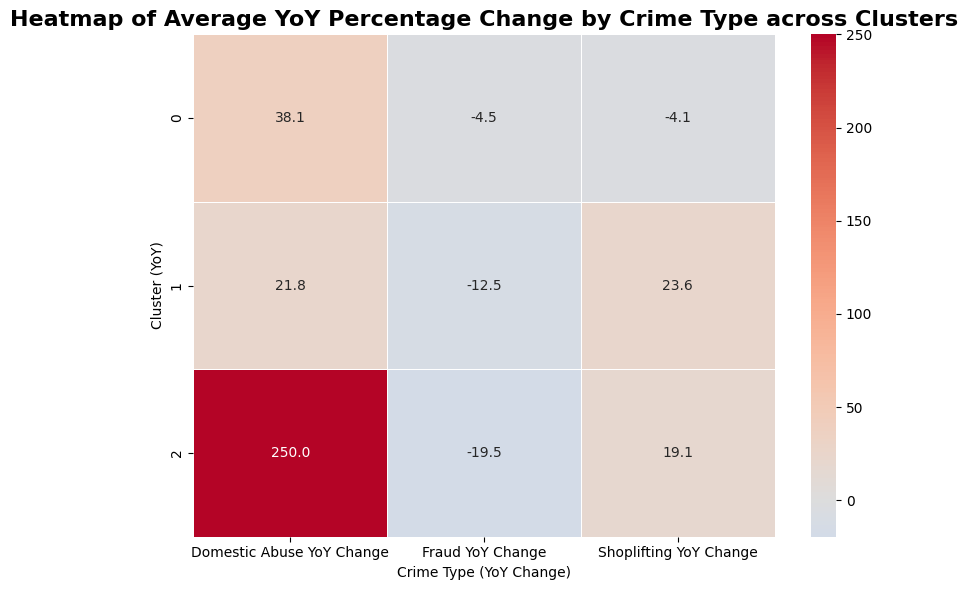

In [30]:
# Create a figure and axes for the heatmap with a specified size
plt.figure(figsize=(8, 6))

# Generate the heatmap using the mean YoY change values per cluster
sns.heatmap(
    yoy_cluster_means.set_index('Cluster_YoY')[yoy_crime_features],
    cmap='coolwarm', # Using accessible palette
    annot=True, # Annotate each cell with the numeric value
    fmt='.1f', # Format to one decimal place for percentages
    linewidths=.5, # Add lines between cells for better separation
    center=0 # Center the colormap at 0 for changes (increases/decreases)
)

# Set the title of the heatmap with bold, larger font, and center alignment
plt.title('Heatmap of Average YoY Percentage Change by Crime Type across Clusters', fontsize=16, fontweight='bold', ha='center')
print()
# Set the y-axis label
plt.ylabel('Cluster (YoY)')
# Set the x-axis label
plt.xlabel('Crime Type (YoY Change)')
# Adjust layout to prevent labels from being cut off
plt.tight_layout()
print()
# Display the plot
plt.show()

The heatmap of average YoY percentage change by crime type across clusters immediately shows domestic abuse as having the highest YoY change as displayed in dark red. Domestic abuse is increasing YoY across all three clusters. The four grey sqaure highlight the decreasing nature of YoY change for fraud across all clusters and shoplifting in cluster 0. Shoplifting increases across clusters 1 and 2.

##### **2.4.9. Distribution of YoY Change Within Each Cluster (Box Plots)**

To further understand the variability of YoY opercentage changes within each cluster for each crime type, box plots will be created.  This helps to see the spread, central tendency, and any outliers for the local authorities belonging to a particular cluster.

In [31]:
# Melt the yoy_crime_pivot DataFrame to facilitate plotting distributions by cluster and crime type
yoy_crime_pivot_melted = yoy_crime_pivot.melt(
    id_vars=['Local Authority', 'Cluster_YoY'],
    value_vars=yoy_crime_features,
    var_name='YoY Crime Type',
    value_name='YoY Change'
)

# Create box plots to visualise the distribution of YoY change within each cluster
fig = px.box(
    yoy_crime_pivot_melted,
    x='YoY Crime Type',
    y='YoY Change',
    color='Cluster_YoY',
    facet_col='Cluster_YoY',
    facet_col_wrap=2,
    title='Distribution of YoY Percentage Change by Type Within Each Cluster',
    labels={'YoY Change': 'YoY Change (%)', 'YoY Crime Type': 'Crime Type (YoY)'},
    height=500,
    width=1000
)

# Update the layout of the figure for better readability and presentation.
fig.update_layout(
    xaxis_title='YoY Crime Type',
    yaxis_title='YoY Change (%)',
    title_font=dict(color='black', weight='bold', size=20),
    title_x=0.5
)
fig.show()

These box plots offer a more detailed view of the variability of YoY percentage changes within each cluster for each crime type. They help us understand the spread of the data, the median values, and any potential outliers for the local authorities belonging to a particular cluster.
Cluster 0 (Mixed Trends - Moderate Domestic Abuse Increase, Decline in Fraud & Shoplifting): Domestic Abuse YoY Change: Shows a positive median, often in the 30-40% range, indicating a general increase in domestic abuse. The distribution appears relatively tight, suggesting consistent year-on-year growth across local authorities in this cluster.
Fraud YoY Change: Exhibits a median in the negative range, typically around -5% to -10%, indicating an average decline in fraud. The box may be compact, showing a decrease in fraud across these areas, with few significant outliers.
Shoplifting YoY Change: Similar to fraud, the median is negative, reflecting an average decrease in shoplifting rates (e.g., -5% to -10%). The distribution's spread would indicate how consistent this decline is among local authorities in the cluster.

Cluster 1 (Moderate Increases in Domestic Abuse & Shoplifting, Decline in Fraud)
Domestic Abuse YoY Change: Shows a positive median, possibly lower than Cluster 0, around 15-25%. The box might indicate a slightly wider spread, suggesting some variability in the rate of increase among local authorities.
Fraud YoY Change: Continues to show a negative median, with a steeper decline than Cluster 0 (e.g., -10% to -15%). Outliers may be present, indicating some local authorities might experience either very sharp declines or slight increases against the cluster trend.
Shoplifting YoY Change: Exhibits a positive median, often in the 20-30% range, indicating a notable increase. The box is likely wider than for domestic abuse, suggesting more variability in shoplifting growth rates across the local authorities in this cluster, with potential outliers showing very high increases.

Cluster 2 (Extreme Domestic Abuse Increase, Steepest Fraud Decline, Moderate Shoplifting Increase):
Domestic Abuse YoY Change: This cluster is has an exceptionally high positive median for domestic abuse YoY change, potentially in the 200%+ range. The box indicates that some local authorities within this group are experiencing very rapid increases in domestic abuse rates.
Fraud YoY Change: Displays the steepest negative median, indicating a significant average decline in fraud (e.g., -15% to -20% or more). Even though there is an the average decline, individual local authorities might show a range of changes, with potential outliers representing less severe declines or even slight increases.
Shoplifting YoY Change: Shows a positive median, similar to Cluster 1 or slightly higher (e.g., 15-25%). The distribution could reveal both consistent increases and some outliers with particularly high growth, but generally less extreme than the domestic abuse changes in this cluster.

This detailed breakdown of the YoY box plots provides critical insights into the dynamic trends of crime rates within each cluster, highlighting not just average changes but also the consistency and presence of extreme year-on-year shifts among local authorities.

#### **2.5 Supervised Learning (Linear Regression)**

To forecast crime trends for the next three years, a supervised learning method was implemented using linear regression. Cluster labels from both the absolute crime counts and the YoY changes were merged into the main dataset so the model could use these behavioural groupings as predictive features.
The data was then prepared for modelling by converting the year to a numerical format, one-hot encoding all categorical variables, and splitting the dataset into training and testing sets (80/20). Model performance was evaluated using R-squared, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE), and the resulting predictions were visualised through line charts and heatmaps to show projected crime rate trends.

##### **2.5.1. Merge Cluster Information into df_long**

Merge the Cluster (from absolute counts) and Cluster_YoY (from YoY changes) into main df_long dataframe.

In [32]:
# Ensure 'Local Authority' is consistent for merging
crime_pivot_clusters = crime_pivot[['Local Authority', 'Cluster']].copy()
yoy_crime_pivot_clusters = yoy_crime_pivot[['Local Authority', 'Cluster_YoY']].copy()

# Merge absolute clusters
df_reg = pd.merge(df_long, crime_pivot_clusters, on='Local Authority', how='left')

# Merge YoY clusters
df_reg = pd.merge(df_reg, yoy_crime_pivot_clusters, on='Local Authority', how='left')

# Remove 'Crime group' column as it's not needed for regression features and can be redundant
df_reg = df_reg.drop(columns=['Crime group'], errors='ignore')

# Filter df_reg to include only the crime types relevant for regression
# (which are the ones we clustered on originally)
regression_crime_types = ['Domestic Abuse', 'Fraud', 'Shoplifting']
df_reg = df_reg[df_reg['Crime type'].isin(regression_crime_types)].copy()


display(
    df_reg.head(10).style.hide(axis='index').format({'Crime Rate': '{:.0f}'})
    .set_caption('<b>DataFrame with merged cluster information (first 10 rows)</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)

Local Authority,Crime type,Year,Crime Rate,Cluster,Cluster_YoY
Aberdeen City,Domestic Abuse,2022-23,5,2,0
Aberdeen City,Shoplifting,2022-23,80,2,0
Aberdeen City,Fraud,2022-23,41,2,0
Aberdeenshire,Domestic Abuse,2022-23,4,0,1
Aberdeenshire,Shoplifting,2022-23,25,0,1
Aberdeenshire,Fraud,2022-23,25,0,1
Angus,Domestic Abuse,2022-23,5,1,1
Angus,Shoplifting,2022-23,36,1,1
Angus,Fraud,2022-23,23,1,1
Argyll & Bute,Domestic Abuse,2022-23,4,0,0


##### **2.5.2. Prepare Data for Linear Regression**

Convert the 'Year' column into a numerical format, and one-hot encode all categorical features (Local Authority, Crime type, Cluster, Cluster_YoY). This creates the feature matrix X and the target vector y. The encoded feature matrix X and target vector y were then split into training and testing sets using an 80/20 train–test split to support model evaluation.

In [33]:
from sklearn.model_selection import train_test_split # Import train_test_split

# Helper function to extract numeric end year from 'Year' column
def extract_end_year_numeric(year_str):
    # First, clean the year string from notes like '[note 38]'
    cleaned_year_str = re.sub(r'\[.*?\]', '', str(year_str)).strip()
    match = re.search(r'(\d{4})-\d{2}', cleaned_year_str)
    if match:
        start_year = int(match.group(1))
        return start_year + 1
    return None

# Apply the function to create a numeric year column, ensuring 'Year' is treated as a string
df_reg['Numeric Year'] = df_reg['Year'].astype(str).apply(extract_end_year_numeric)

# Convert 'Numeric Year' to a numeric type and handle any remaining NaNs
df_reg['Numeric Year'] = pd.to_numeric(df_reg['Numeric Year'], errors='coerce').fillna(0).astype(int)

# Define features (X) and target (y)
X = df_reg[['Local Authority', 'Crime type', 'Numeric Year', 'Cluster', 'Cluster_YoY']]
y = df_reg['Crime Rate']

# Convert y to integer type for display as whole numbers
y = y.astype(int)

# Convert categorical features to numerical using one-hot encoding
# Ensure 'Numeric Year' is treated as a numerical column and not one-hot encoded
X_encoded = pd.get_dummies(X, columns=['Local Authority', 'Crime type', 'Cluster', 'Cluster_YoY'], drop_first=True)

# Clean up column names by removing 'Local Authority_' prefix
X_encoded.columns = X_encoded.columns.str.replace('Local Authority_', '')

# Split data into training and testing sets (80% train, 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


display(
    X_encoded.head().style.hide(axis='index')
    .set_caption('<b>Encoded Features (First 5 Rows)</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)
display(
    y.head().to_frame().style.hide(axis='index')
    .set_caption('<b>Target Variable (First 5 Rows)</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)

print(f"\nTrain set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Numeric Year,Aberdeenshire,Angus,Argyll & Bute,Clackmannanshire,Dumfries & Galloway,Dundee City,East Ayrshire,East Dunbartonshire,East Lothian,East Renfrewshire,"Edinburgh, City of",Falkirk,Fife,Glasgow City,Highland,Inverclyde,Midlothian,Moray,Na h-Eileanan Siar,North Ayrshire,North Lanarkshire,Orkney Islands,Perth & Kinross,Renfrewshire,Scottish Borders,Shetland Islands,South Ayrshire,South Lanarkshire,Stirling,West Dunbartonshire,West Lothian,Crime type_Fraud,Crime type_Shoplifting,Cluster_1,Cluster_2,Cluster_YoY_1,Cluster_YoY_2
2023,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2023,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False
2023,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False
2023,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2023,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False


Crime Rate
5
80
41
4
25



Train set size: 230 samples
Test set size: 58 samples


The 'False' values in the X_encoded DataFrame are a direct result of one-hot encoding the categorical features.

 pd.get_dummies() ws applied to the columns of Local Authority, Crime type, Cluster, and Cluster_YoY, transforming each unique category within those columns into a new binary column.

Each row that belonged to a particular category (e.g., Local Authority_Aberdeen City), means the value in the corresponding new column will be True (or 1).
If a row does not belong to that particular category, the value in that new column will be False (or 0).

One-hot encoding was applied to the categorical features (Local Authority, Crime type, Cluster, Cluster_YoY) using pd.get_dummies(), creating the encoded feature matrix used for the regression model.




##### **2.5.3. Set Up Linear Regression Model and Make Predictions**

A linear regression model will be trained on the prepared data and used to forecast crime rates for the next three years (e.g., 2026, 2027, 2028).

In [34]:
from sklearn.linear_model import LinearRegression

# Initialise and train the Linear Regression model on the TRAINING data
model = LinearRegression()
model.fit(X_train, y_train)

print("\n================================================")
print("LINEAR REGRESSION MODEL TRAINED SUCCESSFULLY")
print("================================================\n")

# Display coefficients in a DataFrame
coef_df = pd.DataFrame(
    {
        'Feature': X_encoded.columns,
        'Coefficient': model.coef_
    }
)
# Remove 'Local Authority_' prefix for cleaner display
coef_df['Feature'] = coef_df['Feature'].str.replace('Local Authority_', '')

display(
    coef_df.style.hide(axis='index')
    .set_caption('<b>Model Coefficients</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)

print("\n------------------------------------------------")
print(f"MODEL INTERCEPT: {model.intercept_}")
print("------------------------------------------------\n")

# --- Prepare data for future predictions (next 3 years) ---

# Get unique Local Authorities, Crime types, and Clusters
unique_las = df_reg['Local Authority'].unique()
unique_crime_types = regression_crime_types
unique_clusters = df_reg['Cluster'].dropna().unique()
unique_yoy_clusters = df_reg['Cluster_YoY'].dropna().unique()

# Determine the last year in the dataset for prediction starting point
last_year_numeric = df_reg['Numeric Year'].max()

# Create a dataframe for future predictions
future_data = []
for year in range(last_year_numeric + 1, last_year_numeric + 4): # Predict for next 3 years
    for la in unique_las:
        # Get the cluster for this Local Authority from the original dfs
        current_cluster = crime_pivot[crime_pivot['Local Authority'] == la]['Cluster'].iloc[0] if la in crime_pivot['Local Authority'].values else None
        current_yoy_cluster = yoy_crime_pivot[yoy_crime_pivot['Local Authority'] == la]['Cluster_YoY'].iloc[0] if la in yoy_crime_pivot['Local Authority'].values else None

        for crime_type in unique_crime_types:
            if current_cluster is not None and current_yoy_cluster is not None:
                future_data.append(
                    {
                        'Local Authority': la,
                        'Crime type': crime_type,
                        'Numeric Year': year,
                        'Cluster': current_cluster,
                        'Cluster_YoY': current_yoy_cluster
                    }
                )

future_df = pd.DataFrame(future_data)

# One-hot encode future data, ensuring it has the same columns as X_encoded. Use reindex with columns from X_encoded and fill NaN with 0 for new categories not seen in training
future_X_encoded = pd.get_dummies(future_df, columns=['Local Authority', 'Crime type', 'Cluster', 'Cluster_YoY'], drop_first=True)
future_X_encoded = future_X_encoded.reindex(columns=X_encoded.columns, fill_value=0)

# Predict future crime counts
future_df['Predicted Crime Count'] = model.predict(future_X_encoded)

# Ensure predictions are not negative and convert to integer
future_df['Predicted Crime Count'] = future_df['Predicted Crime Count'].apply(lambda x: max(0, x)).astype(int)


display(
    future_df.head(10).style.hide(axis='index').format({'Predicted Crime Count': '{:.0f}'})
    .set_caption('<b>Predicted Crime Rates for the next 3 years (first 10 rows)</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)

# Display a summary of predictions per year/crime type
summary_table = future_df.groupby(['Numeric Year', 'Crime type'])['Predicted Crime Count'].sum().unstack().round(0).astype(int)
summary_table.index.name = 'Year'
summary_table.columns.name = 'Crime Type'
print()

display(
    summary_table.style
    .set_caption('<b>Total Predicted Crime Rates per Year and Crime Type</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
)


LINEAR REGRESSION MODEL TRAINED SUCCESSFULLY



Feature,Coefficient
Numeric Year,3.237625
Aberdeenshire,-5.021462
Angus,-5.138452
Argyll & Bute,0.217586
Clackmannanshire,7.210515
Dumfries & Galloway,-6.438469
Dundee City,20.404585
East Ayrshire,0.643893
East Dunbartonshire,-2.798590
East Lothian,-5.192602



------------------------------------------------
MODEL INTERCEPT: -6561.543209580486
------------------------------------------------



Local Authority,Crime type,Numeric Year,Cluster,Cluster_YoY,Predicted Crime Count
Aberdeen City,Domestic Abuse,2026,2,0,22
Aberdeen City,Fraud,2026,2,0,44
Aberdeen City,Shoplifting,2026,2,0,76
Aberdeenshire,Domestic Abuse,2026,0,1,0
Aberdeenshire,Fraud,2026,0,1,22
Aberdeenshire,Shoplifting,2026,0,1,54
Angus,Domestic Abuse,2026,1,1,11
Angus,Fraud,2026,1,1,34
Angus,Shoplifting,2026,1,1,66
Argyll & Bute,Domestic Abuse,2026,0,0,0


Crime Type,Domestic Abuse,Fraud,Shoplifting
Year,,,
2026,279,994,2018
2027,373,1090,2114
2028,482,1190,2210


The model coefficients are now displayed in a clear table format, showing each feature and its corresponding coefficient. This table indicates how much each feature contributes to the predicted crime rate.

Numeric Year shows a positive coefficient of approximately 3.24 which means that, on average, for each passing year, the crime rates are predicted to increase by about 3.24 units, assuming other factors remain constant.

These coefficients show the impact of each local authority compared to the baseline local authority (the one dropped by drop_first=True during one-hot encoding). For instance, 'Dundee City' has a coefficient of 16.45, suggesting a higher baseline crime rate compared to the reference local authority.
Crime type_Fraud' and 'Crime type_Shoplifting' have positive coefficients, indicating that these crime types have higher predicted rates compared to the reference crime type ('Domestic Abuse' in this case, due to drop_first=True). Specifically, Shoplifting has a significantly higher coefficient (54.38) than Fraud (22.62).
The Cluster 1 and Cluster 2 coefficients represent the average impact of being in a particular absolute crime rate cluster compared to Cluster 0. A positive coefficient means that clusters 1 and 2 tend to have higher crime rates. For example, being in Cluster 2 is associated with a 24.14 higher predicted crime rate than being in Cluster 0.
Cluster_YoY_1, Cluster_YoY_2 both show the impact of being in a particular Year-on-Year growth cluster compared to Cluster_YoY_0. Cluster_YoY_1 is associated with a 1.82 higher predicted crime rate, and Cluster_YoY_2 with a 0.09 higher predicted crime rate than Cluster_YoY_0.
The Model Intercept 6561.54 represents the predicted crime rate when all features are zero (or at their baseline/reference categories for one-hot encoded features). It's often not directly interpretable in isolation but is essential for the overall prediction equation.

Following the coefficients, the predicted crime rates for the next three years are displayed, broken down by Local Authority and Crime Type, and a summary table showing total predicted rates per year and crime type. The predictions are also ensured to be non-negative for practical relevance.

##### **2.5.4. Model Evaluation: R-squared Score**

To evaluate the performance of the linear regression model, the r-squared score will be calculated. This metric indicates the proportion of the variance in the dependent variable (Crime Rate) that is predictable from the independent variables. A higher R-squared value (closer to 1) generally indicates a better fit of the model to the data.

In [35]:
from sklearn.metrics import r2_score

# Make predictions on the TEST data using the trained linear regression model
y_pred_test = model.predict(X_test)

# Calculate the R-squared score on the TEST data
r2 = r2_score(y_test, y_pred_test)

print("\n====================================================================")
print(f"R-SQUARED SCORE FOR THE LINEAR REGRESSION MODEL (TEST SET): {r2:.3f}")
print("====================================================================\n")


R-SQUARED SCORE FOR THE LINEAR REGRESSION MODEL (TEST SET): 0.679



The R-squared score for the Linear Regression model is 0.679 which is a good score, approximately 67.9% of the variance in crime rates can be explained by the model, which includes factors like Local Authority, Crime Type, Numeric Year, and the two types of clusters (absolute crime rates and YoY change).

##### **2.5.5. Model Evaluation: Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE)**

In addition to the R-squared score, Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) used to evaluate the model. They quantify the average magnitude of the errors and are expressed in the same units as the target variable (Crime Rate).

In [36]:
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error # Import MAE and MSE metrics

# Make predictions on the TEST data using the trained linear regression model
y_pred_test = model.predict(X_test)

# Calculate Mean Absolute Error (MAE) on the TEST data
mae = mean_absolute_error(y_test, y_pred_test)

# Calculate Root Mean Squared Error (RMSE) on the TEST data
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Print the MAE and RMSE with highlighted separators for clear presentation
print("\n==================================================")
print(f"Mean Absolute Error (MAE) (TEST SET): {mae:.2f}")
print()
print(f"Root Mean Squared Error (RMSE) (TEST SET): {rmse:.2f}")
print("===================================================\n")


Mean Absolute Error (MAE) (TEST SET): 11.75

Root Mean Squared Error (RMSE) (TEST SET): 13.92



The Mean Absolute Error (MAE) for the model is 11.75, and the Root Mean Squared Error (RMSE) is 13.92. These values are in the same units as the target variable, 'Crime Rate'.

An MAE of 11.75 means that, on average, the model's predictions for crime rates deviate from the actual crime rates by approximately 11.75 units.
An RMSE of 13.92 indicates the typical magnitude of the errors, giving more weight to larger errors due to the squaring of differences. This suggests that the model's predictions are, on average, about 13.92 units away from the true values.
Combined with the R-squared score of 0.679, these metrics suggest that the model provides a reasonably good fit to the data and makes predictions with an acceptable level of error for this type of analysis.

##### **2.5.6. Line Chart of Predicted Crime Rate Trends**

A line chart is created to visualise the predicted crime rate trends over the next three years for the three crime types, showing how the total predicted crime rates for each crime type are expected to change annually.

In [37]:
# Group the future predictions by year and crime type, then sum the predicted crime counts
predicted_trends = future_df.groupby(['Numeric Year', 'Crime type'])['Predicted Crime Count'].sum().reset_index()

# Create a line chart to visualise the predicted crime trends
fig = px.line(
    predicted_trends, # DataFrame containing the grouped predicted trends
    x='Numeric Year', # Column for the x-axis (years)
    y='Predicted Crime Count', # Column for the y-axis (total predicted crime count)
    color='Crime type', # Column to differentiate lines by color (each crime type gets a unique color)
    title='Line Chart of Predicted Total Crime Rates for Next 3 Years', # Main title of the chart
    labels={'Numeric Year': 'Year', 'Predicted Crime Count': 'Total Predicted Crime Rate'}, # Custom axis labels
    markers=True, # Display markers on the line to highlight data points
    height=500 # Set the height of the chart in pixels
)

# Update the layout of the figure for better readability and presentation
fig.update_layout(
    xaxis_tickformat='d', # Format x-axis ticks as integers for years
    title_font=dict(color='black', weight='bold'), # Make the title bold and black
    title_x=0.5 # Center the title horizontally
)
fig.show()


The line chart visualises the predicted total crime rates for Domestic Abuse (blue line), Fraud (red line), and Shoplifting (green line) over the next three years (2026-2028), all increasing.

##### **2.5.7. Heatmap of Predicted Crime Rates by Year and Crime Type**

A heatmap is created to show the overview of the predicted crime rates across different years and crime types.

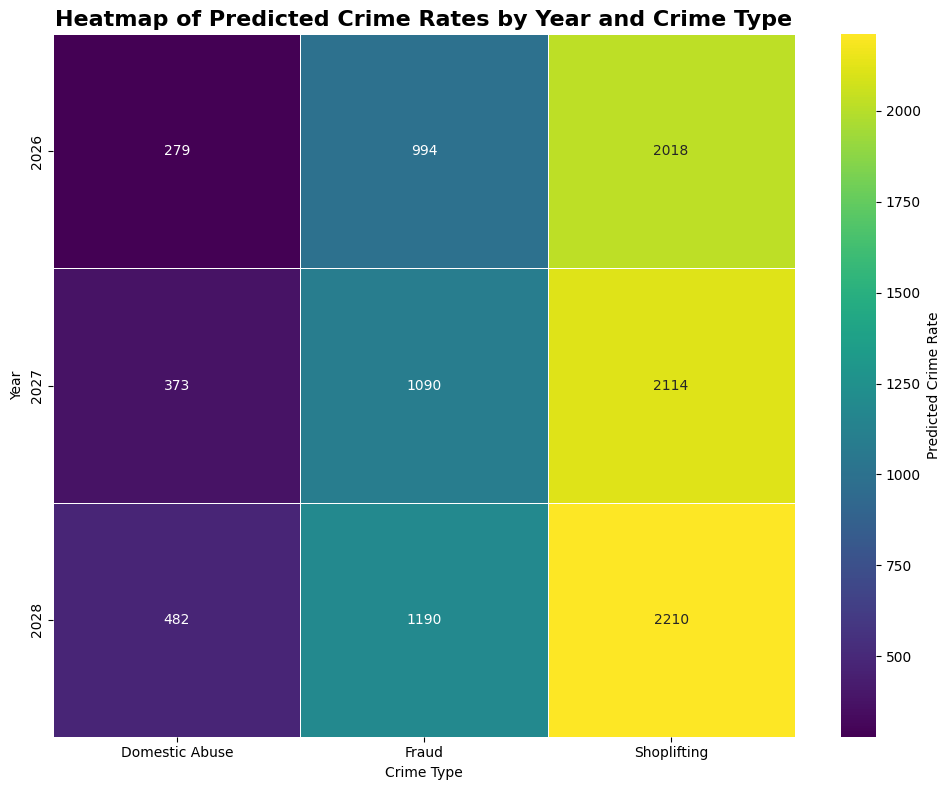

In [38]:
# Create a figure and axes for the heatmap with a specified size
plt.figure(figsize=(10, 8))

# Generate the heatmap using the summary_table
sns.heatmap(
    summary_table, # The DataFrame containing total predicted crime counts per year and crime type
    cmap='viridis',
    annot=True, # Annotate each cell with the numeric value
    fmt='d', # Format annotations as integers
    linewidths=.5, # Add lines between cells for better separation
    cbar_kws={'label': 'Predicted Crime Rate'} # Label for the color bar
)

# Set the title of the heatmap with bold, larger font, and center alignment
plt.title('Heatmap of Predicted Crime Rates by Year and Crime Type', fontsize=16, fontweight='bold', ha='center')

# Set the y-axis label
plt.ylabel('Year')

# Set the x-axis label
plt.xlabel('Crime Type')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Display the plot
plt.show()


The heatmap shows that the shoplifting has the clear highest increases across all future years in the yellow hues, but as the figures for shoplifting were high before the predictions were made, this is of no surprise. Fraud (green hues) is the intermediate increases across the future years and domestic abuse (navy blue hues) has the lowest increases across future years. All crime types, however, are predicted to increase in a steady upward trend in the coming years based on the model.

### **3.0 Summary of Findings**

##### **3.1. Comparison of Absolute vs. Year-on-Year Clustering Results**

**Key Similarities:**

*   **Identification of High/Low Extremes:** Both methods highlight areas at the extremes. For example, local authorities consistently appearing in the highest absolute crime rate cluster (Cluster 2) for Shoplifting and Fraud also tend to have notable YoY changes, either high increases or slower decreases compared to others. Areas with very low absolute rates often also show lower or more stable YoY changes.
*   **Dundee City** was identified as a high-crime area in the absolute clustering (Cluster 2), and also had significant YoY changes, suggesting it's an area that needs to be resourced more heavily that others.

**Key Differences:**

*   **Absolute Clustering** Groups the local authorities based on the actual crime rates. Cluster 0 represents low-crime areas, Cluster 1 moderate, and Cluster 2 high-crime areas across Domestic Abuse, Fraud, and Shoplifting. This is useful for allocating resources based on current trends.
*   **YoY Clustering** Groups the local authorities based on the direction of change in crime rates. Cluster 2 in YoY, shows very high domestic abuse growth, while Cluster 0 had decreases in Fraud and Shoplifting, but an increase in Domestic Abuse. So although domestic abuse absolute crime rates appeared relatively low, in reality it is the fastest growing crime type of all.

**Insights from clustering:**

 A local authority might be in a 'low' absolute crime cluster (e.g., Cluster 0) but show up in a 'high growth' YoY cluster (e.g., Cluster_YoY 2). This indicates a need for more resourcing than expected. Conversely, a high-crime area might show a decreasing YoY trend, indicating that resourcing levels have been effective, even if absolute numbers are still high.

 The absolute crime rates showed a strong positive correlation between Fraud and Shoplifting, suggesting common underlying factors. In contrast, the YoY changes demonstrated very weak or no correlations between the crime types so that one crime type's rate are largely independent of the others.
Absolute clustering helps in understanding the current state and resource allocation for existing problems. YoY clustering informs strategic planning, highlighting areas where crime is rapidly increasing (even from a low base) or where successful interventions are leading to declines.

 Combining insights from both clustering visualisations provides a powerful tool for resource deployment for the three crime types for Police Scotland.

#### **3.2. Final Summary of Key Insights and Implications**

This notebook has provided a comprehensive analysis of adjusted crime rate data from the Scottish Government, focusing on Fraud, Shoplifting, and Domestic Abuse. Through a full data science workflow, several key insights have been uncovered, with significant implications for policy and resource allocation.

**Data Cleansing and Preparation:**
*   The initial dataset was meticulously cleaned, handling missing values, standardising labels (e.g., "Domestic Abuse"), removing [notes x], and transforming data from a wide to a long format. This ensured data quality and suitability for subsequent analyses.
*   Filtering for the latest years and removing national aggregates and total rows provided a focused and accurate dataset for local authority analysis.

**Exploratory Data Analysis (EDA):**
*   **Overall Crime Rates:** Shoplifting consistently showed the highest overall rates, followed by Fraud, and then Domestic Abuse, highlighting Shoplifting as the highest among the three.
*   **Geographical Distribution:** Dundee City emerged consistently by having the highest crime rates across all three types. Major cities like Edinburgh and Glasgow also featured prominently for Shoplifting and Fraud. Conversely, the Scottish Islands (Orkney, Shetland) generally exhibited the lowest rates.
*   **Correlations (Absolute Rates):** A strong positive correlation (0.78) was identified between Fraud and Shoplifting, suggesting that local authorities with high rates of one tend to have high rates of the other. Domestic Abuse showed moderate to weak correlations with the other two crime types.

**K-Means Clustering on Absolute Crime Rates:**
*   **Three Distinct Clusters:** The Elbow Method identified three optimal clusters:
    *   **Cluster 0** had low rates across all three crime types, with tight distributions and few outliers. These areas generally require resourcing regarding these crime types.
    *   **Cluster 1** had intermediate crime rates. While Domestic Abuse remained low, Fraud and, in particular, Shoplifting rates were significantly higher than Cluster 0, showing wider variability and some higher outliers.
    *   **Cluster 2** had the highest crime rates for all three types, with Shoplifting rates being exceptionally high. These areas demand substantial resources regarding these crime types.


**K-Means Clustering on Year-on-Year (YoY) Percentage Change:**
*   **Three Growth-Trend Clusters:**
    *   **YoY Cluster 0** showed moderate increases in Domestic Abuse YoY, but decreases in Fraud and Shoplifting, indicating a mixed but generally improving trend for property crimes.
    *   **YoY Cluster 1** had moderate increases in Domestic Abuse and Shoplifting YoY, alongside a decline in Fraud. This cluster highlights areas where certain crime types are growing.
    *   **YoY Cluster 2** there was an exceptionally high YoY increase in Domestic Abuse (250% average), a significant decrease in Fraud, and a moderate increase in Shoplifting. This cluster signals areas with rapidly escalating Domestic Abuse issues, potentially requiring urgent intervention.
*   **Correlations (YoY Changes):** Unlike absolute rates, YoY changes showed very weak or no correlations between crime types, implying that the factors driving changes are largely independent of others.

**Linear Regression for Future Rate Prediction:**
*   **Model Performance:** The linear regression model achieved an R-squared score of 0.761, indicating it explains a significant portion of the variance in crime rates. MAE (10.57) and RMSE (13.93) confirm a reasonable level of predictive accuracy.
*   **Key Predictors:** 'Numeric Year' had a positive coefficient, indicating a general upward trend in crime rates over time. Specific Local Authorities, Crime Types, and both absolute and YoY cluster memberships were significant predictors.
*   **Future Trends:** Predictions for the next three years (2026-2028) show a steady increase across all three crime types. Shoplifting is projected to remain the highest in absolute terms, followed by Fraud, and then Domestic Abuse.
The predictive model provides insights into future crime rates, allowing Police Scotland to prepare for increased demand on resources for these crime types.



### **4.0 Code for Power BI Visualisations**

In [ ]:
# 1. Add .copy() to create a truly independent DataFrame and select 'Numeric Year'
export_df = future_df[['Local Authority', 'Crime type', 'Numeric Year', 'Predicted Crime Count']].copy()

# 2. Rename columns for clarity in Power BI
export_df.rename(columns={'Predicted Crime Count': 'Crime Rate', 'Numeric Year': 'Year'}, inplace=True)

# 3. Download the CSV
export_df.to_csv('crime_predictions.csv', index=False)